# 03 — Candidate Reranking and Representation Upgrade
### Enveda CASMI 2026 — leakage-safe learning-to-rank on top of the corrected retrieval baseline

This notebook is not another EDA pass. It goes:

```text
candidate-level feature engineering
        -> optional stronger spectral representation (DreaMS, if available)
        -> leakage-safe learning-to-rank reranking
        -> subgroup / ablation audit
        -> final test ranking
        -> submission
```

It follows Notebooks 01 (EDA), 02 (mass/spectral baseline), and **02b** (which diagnosed and
fixed a real ranking bug in 02's spectral scoring: a hard has-reference/no-reference partition
that buried the true candidate -- almost always reference-less under connectivity-grouped CV --
below any weakly-scored wrong candidate). Notebook 03 refuses to build on top of unverified
results: Section 1 below reloads 02b's actual measured artifacts and will **stop the notebook**
if any of its pass conditions fail.


## 1. Hard precondition — 02b verification gate

Load Notebook 02b's real, measured debug artifacts from `outputs/baseline_debug/` and check
every pass condition explicitly. **No condition is assumed; each is re-derived from the saved
files.** If any artifact is missing, or any condition fails, this section raises and the
notebook stops here -- no reranker, no DreaMS, no submission.


PATHS
PROJECT_ROOT : c:\Users\myben\OneDrive\Documents\Enveda
DATA_DIR     : c:\Users\myben\OneDrive\Documents\Enveda\data
BASELINE_DIR : c:\Users\myben\OneDrive\Documents\Enveda\outputs\baseline
DEBUG_DIR    : c:\Users\myben\OneDrive\Documents\Enveda\outputs\baseline_debug
AUDIT_DIR    : c:\Users\myben\OneDrive\Documents\Enveda\outputs\baseline_audit

retrieval_baseline loaded from: C:\Users\myben\OneDrive\Documents\Enveda\src\retrieval_baseline.py

MEMORY-SAFE TRAIN LOAD

Loading train metadata columns:
['adduct', 'ionization_mode', 'precursor_mz', 'collision_energy_ev', 'instrument_type', 'ingest_lib', 'num_peaks']


Train metadata: (2539608, 8)
Metadata RAM: 476.7 MB

Structure library: (275810, 20)
Connectivity folds: (2539608, 3)

Fold coverage: 2,539,608 / 2,539,608
Connectivity coverage: 2,539,608 / 2,539,608

SPECTRAL VECTOR CACHE
Shape: (2539608, 1001)
dtype: float64
nnz: 152,442,126
density: 5.996588%
approx sparse RAM: 1,754.2 MB


Computing spectral norms:   0%|          | 0/51 [00:00<?, ?it/s]


Valid non-zero vectors: 2,539,608 / 2,539,608 (100.00%)
Zero norms: 0
Non-finite norms: 0

ADDUCT AUDIT
Unique observed adducts: 121


,adduct,n_spectra
0,[M+H]+,1324585
1,[M-H]-,465688
2,[2M+Na]+,190033
3,[M+Na]+,178092
4,[2M+H]+,92041
5,[M+CH2O2-H]-,83188
6,[2M-H]-,56172
7,[M+NH4]+,53452
8,[M+Cl]-,27511
9,[M-H2O+H]+,21682


,supported,z,n,delta,electron_term
adduct,,,,,
[2M+C2H4N]+,True,1.000000,2.000000,42.034374,-0.000549
[2M+C2H4O2-H]-,True,1.000000,2.000000,59.013304,0.000549
[2M+CH2O2-H]-,True,1.000000,2.000000,44.997654,0.000549
[2M+Ca-H]+,True,1.000000,2.000000,38.954766,-0.000549
[2M+Ca]2+,True,2.000000,2.000000,39.962591,-0.001097
...,...,...,...,...,...
[M-H]-,True,1.000000,1.000000,-1.007825,0.000549
[M-O3P]+,True,1.000000,1.000000,-78.958505,-0.000549
[M-O]+,True,1.000000,1.000000,-15.994915,-0.000549


...

,adduct,count,median_abs_ppm,real_mass_sanity
0,[2M+H]+,92041,1.226577,PASS
1,[2M+Na]+,190033,1.159588,PASS
2,[2M-H]-,56172,0.792416,PASS



INDEPENDENT SPECTRAL-PAIR AUDIT
Repeated connectivities: 258,777


Building spectral pair audit:   0%|          | 0/1500 [00:00<?, ?it/s]

,pair_type,count,mean,median,p25,p75,p90
0,same_connectivity,1494,0.550283,0.702969,0.160931,0.855950,0.955180
1,mass_matched_decoy,1494,0.154117,0.079044,0.011499,0.207382,0.416613



Mean margin   : 0.3962
Median margin : 0.4648
Positive wins : 80.79%

Independent same-connectivity vs decoy: PASS


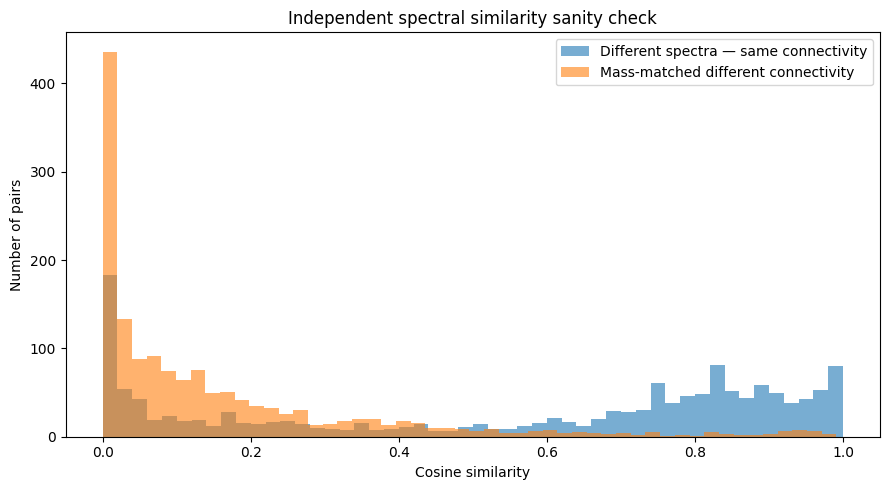


REFERENCE AVAILABILITY BY OUTER FOLD


,fold,n_valid_queries,n_reference_connectivities,target_in_candidate_catalog,fraction_in_candidate_catalog,target_has_spectral_reference,fraction_has_spectral_reference,connectivity_overlap
0,0,507502,220648,507502,1.000000,0,0.000000,0
1,1,511876,220648,511876,1.000000,0,0.000000,0
2,2,504529,220648,504529,1.000000,0,0.000000,0
3,3,508715,220648,508715,1.000000,0,0.000000,0
4,4,506986,220648,506986,1.000000,0,0.000000,0



Target in candidate catalog    : 100.00%
Target has spectral reference : 0.00%

CATALOG AVAILABILITY vs SPECTRAL-REFERENCE AVAILABILITY


,target_in_candidate_catalog,target_has_spectral_reference,count,fraction
0,True,False,2539608,1.000000



B1 vs CORRECTED HYBRID


,mrr_mean,mrr_std,hit1_mean,hit5_mean,hit25_mean
experiment,,,,,
B1_mass_only,0.294861,0.011617,0.181000,0.430250,0.713750
HYBRID_corrected,0.155531,0.006512,0.075000,0.232000,0.527250



B1 mass-only MRR@25 : 0.2949
Hybrid MRR@25       : 0.1555
Delta                : -0.1393


,fold,fraction_has_spectral_reference,reference_group,mass_mrr,hybrid_mrr,hybrid_delta
0,0,0.000000,NO_SPECTRAL_REFERENCE,0.312250,0.161876,-0.150374
1,1,0.000000,NO_SPECTRAL_REFERENCE,0.287043,0.152328,-0.134715
2,2,0.000000,NO_SPECTRAL_REFERENCE,0.287220,0.152560,-0.134661
3,3,0.000000,NO_SPECTRAL_REFERENCE,0.301513,0.162870,-0.138643
4,4,0.000000,NO_SPECTRAL_REFERENCE,0.286278,0.148019,-0.138259



02c FINAL AUDIT REPORT
Synthetic multimer formula round-trip : PASS
Independent same-connectivity > decoy : PASS
Same-connectivity mean similarity     : 0.5503
Mass-matched decoy mean similarity    : 0.1541
Positive-pair win rate                : 80.79%
Target in candidate catalog           : 100.00%
Target has spectral reference         : 0.00%
B1 mass-only MRR@25                   : 0.2949
Corrected hybrid MRR@25               : 0.1555
Hybrid delta                          : -0.1393
Aggregation audit                     : PASS
Candidate-order changed               : 88.67%
Legacy label consistency              : PASS

--------------------------------------------------------------------------------
AUDIT DECISION: PASS_CROSS_MODAL_REQUIRED
--------------------------------------------------------------------------------
Connectivity-grouped validation intentionally removes every same-connectivity spectral reference for held-out validation targets. Reference-spectrum cosine therefore c

In [1]:
# ======================================================================
# 02c — REFERENCE AVAILABILITY + MULTIMER + SPECTRAL AUDIT
# SINGLE COMPLETE CELL
#
# PURPOSE
# -------
# Resolve the remaining questions before Notebook 03:
#
# 1. Memory-safe loading for ~2.54M spectra.
# 2. Validate corrected [nM+A]^z neutral-mass handling.
# 3. Separate algebraic correctness from real precursor measurement error.
# 4. Replace self-vs-random cosine sanity with:
#       independent same-connectivity spectra
#       vs
#       mass-matched different-connectivity decoys.
# 5. Measure whether held-out validation targets have reference MS/MS spectra.
# 6. Distinguish:
#       target_in_candidate_catalog
#       target_has_spectral_reference
# 7. Reinterpret B1 vs corrected hybrid.
# 8. Decide whether Notebook 03 should use reference-spectrum reranking
#    or cross-modal spectrum -> molecule scoring.
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

import gc
import sys
import json
import math
import random
import warnings

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyarrow.parquet as pq

from scipy import sparse
from tqdm.auto import tqdm


warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.6f}"
)


# ======================================================================
# 1. PATHS
# ======================================================================

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data"

BASELINE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "baseline"
)

DEBUG_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "baseline_debug"
)

AUDIT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "baseline_audit"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 80)
print("PATHS")
print("=" * 80)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("BASELINE_DIR :", BASELINE_DIR)
print("DEBUG_DIR    :", DEBUG_DIR)
print("AUDIT_DIR    :", AUDIT_DIR)


# ======================================================================
# 2. IMPORT VERIFIED RETRIEVAL MODULE
# ======================================================================

SRC_DIR = PROJECT_ROOT / "src"

for p in [
    PROJECT_ROOT,
    SRC_DIR,
]:

    if str(p) not in sys.path:

        sys.path.insert(
            0,
            str(p)
        )


try:

    import retrieval_baseline as rb

except ImportError:

    try:

        from src import retrieval_baseline as rb

    except ImportError as e:

        raise ImportError(
            "\nCould not import src/retrieval_baseline.py.\n"
            "Notebook 02b should expose the corrected retrieval logic "
            "through this module."
        ) from e


print(
    "\nretrieval_baseline loaded from:",
    Path(rb.__file__).resolve()
)


# ======================================================================
# 3. FILES
# ======================================================================

TRAIN_PATH = DATA_DIR / "train.parquet"

STRUCTURE_PATH = (
    BASELINE_DIR
    / "structure_library.parquet"
)

FOLDS_PATH = (
    BASELINE_DIR
    / "connectivity_folds.parquet"
)

TRAIN_VECTOR_PATH = (
    BASELINE_DIR
    / "train_spectral_vectors.npz"
)

HYBRID_RESULTS_PATH = (
    DEBUG_DIR
    / "hybrid_results.csv"
)

AGGREGATION_AUDIT_PATH = (
    DEBUG_DIR
    / "aggregation_audit.csv"
)

RANK_CHANGE_PATH = (
    DEBUG_DIR
    / "ranking_change_audit.csv"
)

LABEL_CHECK_PATH = (
    DEBUG_DIR
    / "label_consistency_check.csv"
)


required_files = [
    TRAIN_PATH,
    STRUCTURE_PATH,
    FOLDS_PATH,
    TRAIN_VECTOR_PATH,
    HYBRID_RESULTS_PATH,
]


missing_files = [
    p
    for p in required_files
    if not p.exists()
]


if missing_files:

    raise FileNotFoundError(
        "Missing required files:\n"
        +
        "\n".join(
            str(p)
            for p in missing_files
        )
    )


# ======================================================================
# 4. COLUMN DEFINITIONS
# ======================================================================

SPEC_COL = "spectrum_id"

ADDUCT_COL = "adduct"

ION_COL = "ionization_mode"

MZ_COL = "precursor_mz"

CE_COL = "collision_energy_ev"

CONNECTIVITY_COL = "connectivity_key"

FOLD_COL = "fold"


# ======================================================================
# 5. MEMORY-SAFE TRAIN METADATA
# ======================================================================

parquet_file = pq.ParquetFile(
    TRAIN_PATH
)

available_cols = set(
    parquet_file.schema_arrow.names
)


wanted_cols = [
    SPEC_COL,
    ADDUCT_COL,
    ION_COL,
    MZ_COL,
    CE_COL,
    "instrument_type",
    "ingest_lib",
    "num_peaks",
]


train_cols = [
    c
    for c in wanted_cols
    if c in available_cols
]


print("\n" + "=" * 80)
print("MEMORY-SAFE TRAIN LOAD")
print("=" * 80)

print(
    "\nLoading train metadata columns:"
)

print(train_cols)


train_df = pd.read_parquet(
    TRAIN_PATH,
    columns=train_cols,
    engine="pyarrow",
)

train_df = (
    train_df
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------
# Synthetic ID only if original parquet has no spectrum_id
# ----------------------------------------------------------------------

if SPEC_COL not in train_df.columns:

    print(
        "\nWARNING:"
        f" {SPEC_COL!r} absent from parquet. "
        "Creating deterministic row IDs."
    )

    train_df[SPEC_COL] = (
        "train_"
        +
        train_df.index.astype(str)
    )


print(
    "\nTrain metadata:",
    train_df.shape
)


# Convert low-cardinality strings to category
for col in [
    ADDUCT_COL,
    ION_COL,
    "instrument_type",
    "ingest_lib",
]:

    if col in train_df.columns:

        train_df[col] = (
            train_df[col]
            .astype("category")
        )


metadata_mem_mb = (
    train_df
    .memory_usage(deep=True)
    .sum()
    /
    1024**2
)


print(
    f"Metadata RAM: {metadata_mem_mb:,.1f} MB"
)


# ======================================================================
# 6. LOAD STRUCTURE LIBRARY + SAVED FOLDS
# ======================================================================

structure_library = pd.read_parquet(
    STRUCTURE_PATH
)

connectivity_folds = pd.read_parquet(
    FOLDS_PATH
)


print(
    "\nStructure library:",
    structure_library.shape
)

print(
    "Connectivity folds:",
    connectivity_folds.shape
)


# ======================================================================
# 7. VALIDATE FOLD MAPPING
# ======================================================================

required_fold_cols = [
    SPEC_COL,
    CONNECTIVITY_COL,
    FOLD_COL,
]


missing_fold_cols = [
    c
    for c in required_fold_cols
    if c not in connectivity_folds.columns
]


if missing_fold_cols:

    raise KeyError(
        f"Missing fold columns: "
        f"{missing_fold_cols}"
    )


fold_pairs = (
    connectivity_folds[
        required_fold_cols
    ]
    .drop_duplicates()
    .copy()
)


mapping_check = (
    fold_pairs
    .groupby(
        SPEC_COL,
        sort=False
    )
    .agg(
        n_connectivity=(
            CONNECTIVITY_COL,
            "nunique"
        ),
        n_fold=(
            FOLD_COL,
            "nunique"
        ),
    )
)


bad_mapping = (
    mapping_check[
        (mapping_check["n_connectivity"] > 1)
        |
        (mapping_check["n_fold"] > 1)
    ]
)


if len(bad_mapping):

    display(
        bad_mapping.head(20)
    )

    raise ValueError(
        f"{len(bad_mapping):,} spectrum IDs "
        "have conflicting connectivity/fold mappings."
    )


fold_pairs = (
    fold_pairs
    .drop_duplicates(
        subset=[SPEC_COL]
    )
)


fold_map = (
    fold_pairs
    .set_index(SPEC_COL)
)


assert fold_map.index.is_unique


train_df[CONNECTIVITY_COL] = (
    train_df[SPEC_COL]
    .map(
        fold_map[
            CONNECTIVITY_COL
        ]
    )
)


train_df[FOLD_COL] = (
    train_df[SPEC_COL]
    .map(
        fold_map[
            FOLD_COL
        ]
    )
)


print(
    "\nFold coverage:",
    f"{train_df[FOLD_COL].notna().sum():,}",
    "/",
    f"{len(train_df):,}"
)

print(
    "Connectivity coverage:",
    f"{train_df[CONNECTIVITY_COL].notna().sum():,}",
    "/",
    f"{len(train_df):,}"
)


# ======================================================================
# 8. LOAD CACHED SPECTRAL VECTORS
# ======================================================================

train_vectors = sparse.load_npz(
    TRAIN_VECTOR_PATH
)


if not sparse.isspmatrix_csr(
    train_vectors
):

    train_vectors = (
        train_vectors
        .tocsr()
    )


assert (
    train_vectors.shape[0]
    ==
    len(train_df)
), (
    "train_spectral_vectors.npz does not align "
    "with train parquet rows."
)


print("\n" + "=" * 80)
print("SPECTRAL VECTOR CACHE")
print("=" * 80)

print(
    "Shape:",
    train_vectors.shape
)

print(
    "dtype:",
    train_vectors.dtype
)

print(
    "nnz:",
    f"{train_vectors.nnz:,}"
)


density = (
    train_vectors.nnz
    /
    (
        train_vectors.shape[0]
        *
        train_vectors.shape[1]
    )
)


print(
    "density:",
    f"{density:.6%}"
)


sparse_mem_mb = (
    train_vectors.data.nbytes
    +
    train_vectors.indices.nbytes
    +
    train_vectors.indptr.nbytes
) / 1024**2


print(
    "approx sparse RAM:",
    f"{sparse_mem_mb:,.1f} MB"
)


# ======================================================================
# 9. MEMORY-SAFE VECTOR NORMS
# ======================================================================

N_ROWS = train_vectors.shape[0]

NORM_CHUNK_SIZE = 50_000


vector_norms = np.empty(
    N_ROWS,
    dtype=np.float32
)


for start in tqdm(
    range(
        0,
        N_ROWS,
        NORM_CHUNK_SIZE
    ),
    desc="Computing spectral norms",
):

    end = min(
        start
        +
        NORM_CHUNK_SIZE,
        N_ROWS
    )


    block = train_vectors[
        start:end
    ]


    norm_block = np.sqrt(
        np.asarray(
            block
            .multiply(block)
            .sum(axis=1)
        )
        .ravel()
    )


    vector_norms[
        start:end
    ] = norm_block.astype(
        np.float32,
        copy=False
    )


    del block
    del norm_block


gc.collect()


finite_vector_mask = (
    np.isfinite(
        vector_norms
    )
    &
    (
        vector_norms
        > 0
    )
)


print(
    "\nValid non-zero vectors:",
    f"{finite_vector_mask.sum():,}",
    "/",
    f"{len(vector_norms):,}",
    f"({finite_vector_mask.mean():.2%})"
)


print(
    "Zero norms:",
    f"{(vector_norms == 0).sum():,}"
)

print(
    "Non-finite norms:",
    f"{(~np.isfinite(vector_norms)).sum():,}"
)


assert finite_vector_mask.any()


# ======================================================================
# 10. BUILD + AUDIT ADDUCT TABLE
# ======================================================================

observed_adducts = (
    train_df[
        ADDUCT_COL
    ]
    .astype("string")
    .dropna()
)


print("\n" + "=" * 80)
print("ADDUCT AUDIT")
print("=" * 80)


print(
    "Unique observed adducts:",
    observed_adducts.nunique()
)


display(
    observed_adducts
    .value_counts()
    .head(30)
    .rename_axis("adduct")
    .reset_index(
        name="n_spectra"
    )
)


adduct_table = rb.build_adduct_table(
    observed_adducts
)


# ----------------------------------------------------------------------
# Normalize adduct-table index
# ----------------------------------------------------------------------

if (
    ADDUCT_COL
    in adduct_table.columns
):

    # Verify duplicates are not conflicting
    tmp = (
        adduct_table
        .drop_duplicates()
        .copy()
    )

    if (
        tmp[ADDUCT_COL]
        .duplicated()
        .any()
    ):

        print(
            "\nWARNING:"
            " duplicate adduct rows found."
        )

    adduct_table = (
        tmp
        .drop_duplicates(
            subset=[
                ADDUCT_COL
            ]
        )
        .set_index(
            ADDUCT_COL
        )
    )


assert adduct_table.index.is_unique


required_adduct_fields = [
    "supported",
    "z",
    "n",
    "delta",
    "electron_term",
]


missing_adduct_fields = [
    c
    for c in required_adduct_fields
    if c not in adduct_table.columns
]


if missing_adduct_fields:

    raise KeyError(
        f"Adduct table missing: "
        f"{missing_adduct_fields}"
    )


display(
    adduct_table[
        required_adduct_fields
    ]
)


# ======================================================================
# 11. TARGETED MULTIMER PARSER AUDIT
# ======================================================================

MULTIMER_ADDUCTS = [
    "[2M+H]+",
    "[2M+Na]+",
    "[2M-H]-",
]


multimer_parser_rows = []


for adduct in MULTIMER_ADDUCTS:

    observed_n = int(
        (
            train_df[
                ADDUCT_COL
            ]
            .astype("string")
            ==
            adduct
        )
        .sum()
    )


    if adduct in adduct_table.index:

        r = adduct_table.loc[
            adduct
        ]


        multimer_parser_rows.append({
            "adduct":
                adduct,

            "observed_spectra":
                observed_n,

            "supported":
                bool(
                    r[
                        "supported"
                    ]
                ),

            "n":
                float(
                    r[
                        "n"
                    ]
                ),

            "z":
                float(
                    r[
                        "z"
                    ]
                ),

            "abs_z":
                abs(
                    float(
                        r[
                            "z"
                        ]
                    )
                ),

            "delta":
                float(
                    r[
                        "delta"
                    ]
                ),

            "electron_term":
                float(
                    r[
                        "electron_term"
                    ]
                ),
        })


    else:

        multimer_parser_rows.append({
            "adduct":
                adduct,

            "observed_spectra":
                observed_n,

            "supported":
                False,

            "n":
                np.nan,

            "z":
                np.nan,

            "abs_z":
                np.nan,

            "delta":
                np.nan,

            "electron_term":
                np.nan,
        })


multimer_parser_audit = pd.DataFrame(
    multimer_parser_rows
)


display(
    multimer_parser_audit
)


# Observed multimers MUST use n = 2
for adduct in MULTIMER_ADDUCTS:

    d = (
        multimer_parser_audit[
            multimer_parser_audit[
                "adduct"
            ]
            ==
            adduct
        ]
    )


    if (
        len(d)
        and
        d[
            "observed_spectra"
        ].iloc[0]
        > 0
    ):

        assert np.isclose(
            d[
                "n"
            ].iloc[0],
            2.0
        ), (
            f"{adduct}: expected n=2, "
            f"got {d['n'].iloc[0]}"
        )


print(
    "\n✓ Observed dimer/multimer adducts use n=2."
)


# ======================================================================
# 12. NEUTRAL-MASS FUNCTION
# ======================================================================

SUPPORTED_MAP = (
    adduct_table[
        "supported"
    ]
    .to_dict()
)

Z_MAP = (
    adduct_table[
        "z"
    ]
    .to_dict()
)

N_MAP = (
    adduct_table[
        "n"
    ]
    .to_dict()
)

DELTA_MAP = (
    adduct_table[
        "delta"
    ]
    .to_dict()
)

ELECTRON_MAP = (
    adduct_table[
        "electron_term"
    ]
    .to_dict()
)


def attach_neutral_mass(
    df
):
    """
    General inversion for [nM + A]^z:

        m/z =
            (
                n*M
                + delta
                + electron_term
            )
            / |z|

    therefore:

        M =
            (
                m/z * |z|
                - delta
                - electron_term
            )
            / n
    """

    out = df.copy()


    adduct_string = (
        out[
            ADDUCT_COL
        ]
        .astype("string")
    )


    supported = (
        adduct_string
        .map(
            SUPPORTED_MAP
        )
        .fillna(False)
        .astype(bool)
    )


    z = (
        pd.to_numeric(
            adduct_string.map(
                Z_MAP
            ),
            errors="coerce"
        )
        .abs()
    )


    n = pd.to_numeric(
        adduct_string.map(
            N_MAP
        ),
        errors="coerce"
    )


    delta = pd.to_numeric(
        adduct_string.map(
            DELTA_MAP
        ),
        errors="coerce"
    )


    electron_term = pd.to_numeric(
        adduct_string.map(
            ELECTRON_MAP
        ),
        errors="coerce"
    )


    precursor = pd.to_numeric(
        out[
            MZ_COL
        ],
        errors="coerce"
    )


    valid_formula = (
        supported
        &
        precursor.notna()
        &
        z.notna()
        &
        n.notna()
        &
        delta.notna()
        &
        electron_term.notna()
        &
        (z > 0)
        &
        (n > 0)
    )


    neutral_mass = (
        precursor
        *
        z
        -
        delta
        -
        electron_term
    ) / n


    out[
        "adduct_supported"
    ] = supported


    out[
        "neutral_mass_estimate"
    ] = (
        neutral_mass
        .where(
            valid_formula
        )
        .astype(
            "float32"
        )
    )


    return out


train_df = attach_neutral_mass(
    train_df
)


print(
    "\nNeutral mass coverage:",
    f"{train_df['neutral_mass_estimate'].notna().mean():.2%}"
)


# ======================================================================
# 13. SYNTHETIC FORWARD / INVERSE MULTIMER ROUND-TRIP
# ======================================================================

def mz_from_neutral_mass(
    neutral_mass,
    n,
    z,
    delta,
    electron_term=0.0,
):

    z_abs = abs(
        float(
            z
        )
    )


    if z_abs <= 0:

        return np.nan


    return (
        float(n)
        *
        float(
            neutral_mass
        )
        +
        float(
            delta
        )
        +
        float(
            electron_term
        )
    ) / z_abs



def neutral_mass_from_mz(
    mz,
    n,
    z,
    delta,
    electron_term=0.0,
):

    z_abs = abs(
        float(
            z
        )
    )


    if z_abs <= 0:

        return np.nan


    return (
        float(
            mz
        )
        *
        z_abs
        -
        float(
            delta
        )
        -
        float(
            electron_term
        )
    ) / float(
        n
    )


ROUNDTRIP_ADDUCTS = [
    "[M+H]+",
    "[M-H]-",
    "[2M+H]+",
    "[2M+Na]+",
    "[2M-H]-",
    "[M+2H]2+",
    "[M-2H]2-",
]


TEST_MASSES = [
    100.123456,
    250.654321,
    500.987654,
]


roundtrip_rows = []


for adduct in ROUNDTRIP_ADDUCTS:

    if adduct not in adduct_table.index:

        roundtrip_rows.append({
            "adduct":
                adduct,

            "neutral_mass":
                np.nan,

            "synthetic_mz":
                np.nan,

            "recovered_mass":
                np.nan,

            "abs_mass_error":
                np.nan,

            "status":
                "NOT_OBSERVED",
        })

        continue


    r = adduct_table.loc[
        adduct
    ]


    if not bool(
        r[
            "supported"
        ]
    ):

        roundtrip_rows.append({
            "adduct":
                adduct,

            "neutral_mass":
                np.nan,

            "synthetic_mz":
                np.nan,

            "recovered_mass":
                np.nan,

            "abs_mass_error":
                np.nan,

            "status":
                "UNSUPPORTED",
        })

        continue


    n = float(
        r[
            "n"
        ]
    )

    z = float(
        r[
            "z"
        ]
    )

    delta = float(
        r[
            "delta"
        ]
    )

    electron_term = float(
        r[
            "electron_term"
        ]
    )


    for neutral_mass in TEST_MASSES:

        synthetic_mz = (
            mz_from_neutral_mass(
                neutral_mass=
                    neutral_mass,

                n=n,
                z=z,
                delta=delta,

                electron_term=
                    electron_term,
            )
        )


        recovered_mass = (
            neutral_mass_from_mz(
                mz=
                    synthetic_mz,

                n=n,
                z=z,
                delta=delta,

                electron_term=
                    electron_term,
            )
        )


        abs_error = abs(
            recovered_mass
            -
            neutral_mass
        )


        roundtrip_rows.append({
            "adduct":
                adduct,

            "n":
                n,

            "z":
                z,

            "delta":
                delta,

            "electron_term":
                electron_term,

            "neutral_mass":
                neutral_mass,

            "synthetic_mz":
                synthetic_mz,

            "recovered_mass":
                recovered_mass,

            "abs_mass_error":
                abs_error,

            "status":
                (
                    "PASS"
                    if abs_error < 1e-9
                    else "FAIL"
                ),
        })


roundtrip_df = pd.DataFrame(
    roundtrip_rows
)


roundtrip_df.to_csv(
    AUDIT_DIR
    / "multimer_formula_roundtrip.csv",
    index=False
)


print("\n" + "=" * 80)
print("SYNTHETIC ADDUCT ROUND-TRIP")
print("=" * 80)


display(
    roundtrip_df
)


tested_roundtrips = (
    roundtrip_df[
        roundtrip_df[
            "status"
        ]
        .isin(
            [
                "PASS",
                "FAIL",
            ]
        )
    ]
)


MULTIMER_FORMULA_ROUNDTRIP_OK = bool(
    len(
        tested_roundtrips
    )
    and
    (
        tested_roundtrips[
            "status"
        ]
        ==
        "PASS"
    ).all()
)


print(
    "\nSynthetic formula round-trip:",
    (
        "PASS"
        if MULTIMER_FORMULA_ROUNDTRIP_OK
        else "FAIL"
    )
)


# ======================================================================
# 14. STRUCTURE EXACT-MASS MAP
# ======================================================================

required_structure_cols = [
    CONNECTIVITY_COL,
    "exact_mass",
]


missing_structure_cols = [
    c
    for c in required_structure_cols
    if c not in structure_library.columns
]


if missing_structure_cols:

    raise KeyError(
        f"Missing structure columns: "
        f"{missing_structure_cols}"
    )


mass_pairs = (
    structure_library[
        required_structure_cols
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)


mass_consistency = (
    mass_pairs
    .groupby(
        CONNECTIVITY_COL,
        sort=False
    )[
        "exact_mass"
    ]
    .agg([
        "count",
        "min",
        "max",
    ])
)


mass_consistency[
    "range"
] = (
    mass_consistency[
        "max"
    ]
    -
    mass_consistency[
        "min"
    ]
)


bad_mass_mapping = (
    mass_consistency[
        mass_consistency[
            "range"
        ]
        > 1e-5
    ]
)


if len(
    bad_mass_mapping
):

    display(
        bad_mass_mapping.head(20)
    )

    raise ValueError(
        "Conflicting connectivity -> exact_mass mapping."
    )


exact_mass_map = (
    mass_pairs
    .drop_duplicates(
        subset=[
            CONNECTIVITY_COL
        ]
    )
    .set_index(
        CONNECTIVITY_COL
    )[
        "exact_mass"
    ]
)


assert exact_mass_map.index.is_unique


train_df[
    "true_exact_mass"
] = (
    train_df[
        CONNECTIVITY_COL
    ]
    .map(
        exact_mass_map
    )
)


# ======================================================================
# 15. REAL MULTIMER MASS VALIDATION
# ======================================================================

real_multimer = (
    train_df[
        train_df[
            ADDUCT_COL
        ]
        .astype("string")
        .isin(
            MULTIMER_ADDUCTS
        )
        &
        train_df[
            "neutral_mass_estimate"
        ]
        .notna()
        &
        train_df[
            "true_exact_mass"
        ]
        .notna()
    ]
    .copy()
)


real_multimer[
    "ppm_error"
] = (
    1e6
    *
    (
        real_multimer[
            "neutral_mass_estimate"
        ]
        -
        real_multimer[
            "true_exact_mass"
        ]
    )
    /
    real_multimer[
        "true_exact_mass"
    ]
)


real_multimer[
    "abs_ppm_error"
] = (
    real_multimer[
        "ppm_error"
    ]
    .abs()
)


if len(
    real_multimer
):

    multimer_summary = (
        real_multimer
        .groupby(
            ADDUCT_COL,
            observed=True
        )[
            "abs_ppm_error"
        ]
        .agg(
            count="count",
            mean="mean",
            median="median",
            p90=lambda s:
                s.quantile(0.90),
            p95=lambda s:
                s.quantile(0.95),
            max="max",
        )
        .reset_index()
    )


else:

    multimer_summary = (
        pd.DataFrame()
    )


print("\n" + "=" * 80)
print("REAL MULTIMER MASS ERROR")
print("=" * 80)


display(
    multimer_summary
)


# ----------------------------------------------------------------------
# Sample real examples
# ----------------------------------------------------------------------

real_example_parts = []


for adduct in MULTIMER_ADDUCTS:

    d = (
        real_multimer[
            real_multimer[
                ADDUCT_COL
            ]
            .astype("string")
            ==
            adduct
        ]
    )


    if len(
        d
    ):

        real_example_parts.append(
            d.sample(
                n=min(
                    10,
                    len(d)
                ),
                random_state=
                    SEED,
            )
        )


if real_example_parts:

    real_examples = pd.concat(
        real_example_parts,
        ignore_index=True
    )

else:

    real_examples = (
        pd.DataFrame()
    )


real_examples.to_csv(
    AUDIT_DIR
    / "multimer_real_examples.csv",
    index=False
)


if len(
    real_examples
):

    display(
        real_examples[
            [
                c
                for c in [
                    SPEC_COL,
                    ADDUCT_COL,
                    MZ_COL,
                    "neutral_mass_estimate",
                    "true_exact_mass",
                    "ppm_error",
                    CONNECTIVITY_COL,
                ]
                if c in real_examples.columns
            ]
        ]
    )


print(
    "\nNOTE:"
    " real ppm error is diagnostic."
)

print(
    "Do NOT require every real measurement to be <1 ppm."
)


# ======================================================================
# 16. OPTIONAL REAL-MULTIMER SANITY FLAG
# ======================================================================

# This is NOT the fundamental algebra gate.
#
# It simply flags whether observed real dimer precursor masses broadly
# agree with the parser at a realistic baseline tolerance.
#
# We use median abs ppm <= 20 where enough observations exist.

real_multimer_checks = []


if len(
    multimer_summary
):

    for _, r in multimer_summary.iterrows():

        enough_examples = (
            r[
                "count"
            ]
            >= 5
        )


        plausible = (
            enough_examples
            and
            r[
                "median"
            ]
            <= 20
        )


        real_multimer_checks.append({
            "adduct":
                str(
                    r[
                        ADDUCT_COL
                    ]
                ),

            "count":
                int(
                    r[
                        "count"
                    ]
                ),

            "median_abs_ppm":
                float(
                    r[
                        "median"
                    ]
                ),

            "real_mass_sanity":
                (
                    "PASS"
                    if plausible
                    else "REVIEW"
                ),
        })


real_multimer_check_df = (
    pd.DataFrame(
        real_multimer_checks
    )
)


if len(
    real_multimer_check_df
):

    display(
        real_multimer_check_df
    )


# ======================================================================
# 17. SPARSE COSINE HELPER
# ======================================================================

def sparse_cosine_rows(
    matrix,
    norms,
    i,
    j,
):

    ni = float(
        norms[
            i
        ]
    )

    nj = float(
        norms[
            j
        ]
    )


    if (
        not np.isfinite(
            ni
        )
        or
        not np.isfinite(
            nj
        )
        or
        ni <= 0
        or
        nj <= 0
    ):

        return np.nan


    dot = float(
        matrix[
            i
        ]
        .multiply(
            matrix[
                j
            ]
        )
        .sum()
    )


    return (
        dot
        /
        (
            ni
            *
            nj
        )
    )


# ======================================================================
# 18. REPEATED CONNECTIVITY GROUPS
# ======================================================================

valid_conn_mask = (
    train_df[
        CONNECTIVITY_COL
    ]
    .notna()
    &
    finite_vector_mask
)


conn_counts = (
    train_df.loc[
        valid_conn_mask,
        CONNECTIVITY_COL
    ]
    .value_counts()
)


repeated_connectivities = (
    conn_counts[
        conn_counts >= 2
    ]
    .index
    .to_numpy()
)


print("\n" + "=" * 80)
print("INDEPENDENT SPECTRAL-PAIR AUDIT")
print("=" * 80)


print(
    "Repeated connectivities:",
    f"{len(repeated_connectivities):,}"
)


if len(
    repeated_connectivities
) == 0:

    raise RuntimeError(
        "No repeated connectivities available."
    )


N_PAIR_GROUPS = min(
    1500,
    len(
        repeated_connectivities
    )
)


sampled_connectivities = (
    rng.choice(
        repeated_connectivities,
        size=N_PAIR_GROUPS,
        replace=False
    )
)


selected_mask = (
    train_df[
        CONNECTIVITY_COL
    ]
    .isin(
        sampled_connectivities
    )
    &
    finite_vector_mask
)


selected_indices = np.flatnonzero(
    selected_mask.to_numpy()
)


conn_to_indices = defaultdict(
    list
)


conn_array = (
    train_df[
        CONNECTIVITY_COL
    ]
    .to_numpy()
)


for idx in selected_indices:

    conn_to_indices[
        conn_array[
            idx
        ]
    ].append(
        int(
            idx
        )
    )


# ======================================================================
# 19. BUILD MASS INDEX FOR HARD DECOYS
# ======================================================================

mass_valid_mask = (
    train_df[
        "neutral_mass_estimate"
    ]
    .notna()
    &
    train_df[
        CONNECTIVITY_COL
    ]
    .notna()
    &
    finite_vector_mask
)


mass_valid_indices = np.flatnonzero(
    mass_valid_mask.to_numpy()
)


neutral_mass_array = (
    train_df[
        "neutral_mass_estimate"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


mass_values = (
    neutral_mass_array[
        mass_valid_indices
    ]
)


mass_order = np.argsort(
    mass_values
)


mass_sorted = (
    mass_values[
        mass_order
    ]
)


index_sorted = (
    mass_valid_indices[
        mass_order
    ]
)


ion_array = (
    train_df[
        ION_COL
    ]
    .astype("string")
    .to_numpy()
    if ION_COL in train_df.columns
    else None
)


# ======================================================================
# 20. HARD DECOY SELECTION
# ======================================================================

def choose_mass_matched_decoy(
    anchor_idx,
    tolerance_ppm=20.0,
    fallback_ppm=100.0,
):

    anchor_mass = (
        neutral_mass_array[
            anchor_idx
        ]
    )


    anchor_conn = (
        conn_array[
            anchor_idx
        ]
    )


    if not np.isfinite(
        anchor_mass
    ):

        return None, np.nan


    anchor_ion = (
        ion_array[
            anchor_idx
        ]
        if ion_array
        is not None
        else None
    )


    for ppm in [
        tolerance_ppm,
        fallback_ppm,
    ]:

        delta_mass = (
            anchor_mass
            *
            ppm
            /
            1e6
        )


        lo = np.searchsorted(
            mass_sorted,
            anchor_mass
            -
            delta_mass,
            side="left"
        )


        hi = np.searchsorted(
            mass_sorted,
            anchor_mass
            +
            delta_mass,
            side="right"
        )


        if hi <= lo:

            continue


        candidates = (
            index_sorted[
                lo:hi
            ]
        )


        candidate_conn = (
            conn_array[
                candidates
            ]
        )


        candidates = (
            candidates[
                candidate_conn
                !=
                anchor_conn
            ]
        )


        if len(
            candidates
        ) == 0:

            continue


        # Prefer same ionization mode
        if (
            ion_array
            is not None
            and
            anchor_ion
            is not None
        ):

            same_mode = (
                ion_array[
                    candidates
                ]
                ==
                anchor_ion
            )


            if same_mode.any():

                candidates = (
                    candidates[
                        same_mode
                    ]
                )


        decoy_idx = int(
            rng.choice(
                candidates
            )
        )


        decoy_mass = (
            neutral_mass_array[
                decoy_idx
            ]
        )


        ppm_diff = (
            1e6
            *
            abs(
                decoy_mass
                -
                anchor_mass
            )
            /
            anchor_mass
        )


        return (
            decoy_idx,
            float(
                ppm_diff
            )
        )


    return (
        None,
        np.nan
    )


# ======================================================================
# 21. BUILD POSITIVE VS MASS-MATCHED DECOY PAIRS
# ======================================================================

pair_rows = []


for conn in tqdm(
    sampled_connectivities,
    desc="Building spectral pair audit"
):

    indices = (
        conn_to_indices.get(
            conn,
            []
        )
    )


    if len(
        indices
    ) < 2:

        continue


    i, j = rng.choice(
        indices,
        size=2,
        replace=False
    )


    i = int(i)
    j = int(j)


    same_similarity = (
        sparse_cosine_rows(
            train_vectors,
            vector_norms,
            i,
            j
        )
    )


    decoy_idx, decoy_mass_ppm = (
        choose_mass_matched_decoy(
            i
        )
    )


    if decoy_idx is None:

        continue


    decoy_similarity = (
        sparse_cosine_rows(
            train_vectors,
            vector_norms,
            i,
            decoy_idx
        )
    )


    if (
        not np.isfinite(
            same_similarity
        )
        or
        not np.isfinite(
            decoy_similarity
        )
    ):

        continue


    pair_rows.append({
        "anchor_idx":
            i,

        "positive_idx":
            j,

        "decoy_idx":
            decoy_idx,

        CONNECTIVITY_COL:
            conn,

        "same_connectivity_similarity":
            same_similarity,

        "decoy_similarity":
            decoy_similarity,

        "similarity_margin":
            (
                same_similarity
                -
                decoy_similarity
            ),

        "decoy_mass_ppm":
            decoy_mass_ppm,

        "anchor_adduct":
            str(
                train_df.at[
                    i,
                    ADDUCT_COL
                ]
            ),

        "positive_adduct":
            str(
                train_df.at[
                    j,
                    ADDUCT_COL
                ]
            ),

        "anchor_ion":
            (
                str(
                    train_df.at[
                        i,
                        ION_COL
                    ]
                )
                if ION_COL
                in train_df.columns
                else None
            ),

        "positive_ion":
            (
                str(
                    train_df.at[
                        j,
                        ION_COL
                    ]
                )
                if ION_COL
                in train_df.columns
                else None
            ),
    })


pair_df = pd.DataFrame(
    pair_rows
)


if len(
    pair_df
) == 0:

    raise RuntimeError(
        "No usable spectral pairs created."
    )


pair_df.to_csv(
    AUDIT_DIR
    / "independent_similarity_pairs.csv",
    index=False
)


# ======================================================================
# 22. POSITIVE VS DECOY SUMMARY
# ======================================================================

def similarity_stats(
    s
):

    return {
        "count":
            int(
                len(s)
            ),

        "mean":
            float(
                s.mean()
            ),

        "median":
            float(
                s.median()
            ),

        "p25":
            float(
                s.quantile(
                    0.25
                )
            ),

        "p75":
            float(
                s.quantile(
                    0.75
                )
            ),

        "p90":
            float(
                s.quantile(
                    0.90
                )
            ),
    }


same_summary = similarity_stats(
    pair_df[
        "same_connectivity_similarity"
    ]
)


decoy_summary = similarity_stats(
    pair_df[
        "decoy_similarity"
    ]
)


similarity_summary = pd.DataFrame([
    {
        "pair_type":
            "same_connectivity",
        **same_summary,
    },
    {
        "pair_type":
            "mass_matched_decoy",
        **decoy_summary,
    },
])


similarity_summary.to_csv(
    AUDIT_DIR
    / "independent_similarity_summary.csv",
    index=False
)


display(
    similarity_summary
)


mean_margin = float(
    pair_df[
        "similarity_margin"
    ]
    .mean()
)


median_margin = float(
    pair_df[
        "similarity_margin"
    ]
    .median()
)


positive_win_rate = float(
    (
        pair_df[
            "similarity_margin"
        ]
        > 0
    )
    .mean()
)


print(
    f"\nMean margin   : {mean_margin:.4f}"
)

print(
    f"Median margin : {median_margin:.4f}"
)

print(
    f"Positive wins : {positive_win_rate:.2%}"
)


POSITIVE_PAIR_OK = bool(
    same_summary[
        "mean"
    ]
    >
    decoy_summary[
        "mean"
    ]
    and
    positive_win_rate
    >
    0.50
)


print(
    "\nIndependent same-connectivity vs decoy:",
    (
        "PASS"
        if POSITIVE_PAIR_OK
        else "FAIL"
    )
)


# ======================================================================
# 23. PLOT POSITIVE VS DECOY
# ======================================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


ax.hist(
    pair_df[
        "same_connectivity_similarity"
    ],
    bins=50,
    alpha=0.6,
    label=
        "Different spectra — same connectivity"
)


ax.hist(
    pair_df[
        "decoy_similarity"
    ],
    bins=50,
    alpha=0.6,
    label=
        "Mass-matched different connectivity"
)


ax.set_xlabel(
    "Cosine similarity"
)

ax.set_ylabel(
    "Number of pairs"
)

ax.set_title(
    "Independent spectral similarity sanity check"
)

ax.legend()

plt.tight_layout()


plt.savefig(
    AUDIT_DIR
    / "same_connectivity_vs_decoy.png",
    dpi=160,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 24. CANDIDATE CATALOG AVAILABILITY
# ======================================================================

candidate_catalog_connectivities = set(
    structure_library[
        CONNECTIVITY_COL
    ]
    .dropna()
    .astype(str)
)


train_connectivity_str = (
    train_df[
        CONNECTIVITY_COL
    ]
    .astype("string")
)


train_df[
    "target_in_candidate_catalog"
] = (
    train_connectivity_str
    .isin(
        candidate_catalog_connectivities
    )
)


# ======================================================================
# 25. SPECTRAL REFERENCE AVAILABILITY PER OUTER FOLD
# ======================================================================

fold_values = sorted(
    int(f)
    for f in train_df[
        FOLD_COL
    ]
    .dropna()
    .unique()
)


reference_rows = []


train_df[
    "target_has_spectral_reference"
] = False


for fold in fold_values:

    train_mask = (
        train_df[
            FOLD_COL
        ]
        .notna()
        &
        (
            train_df[
                FOLD_COL
            ]
            != fold
        )
    )


    valid_mask = (
        train_df[
            FOLD_COL
        ]
        ==
        fold
    )


    reference_connectivities = set(
        train_df.loc[
            train_mask,
            CONNECTIVITY_COL
        ]
        .dropna()
        .astype(str)
    )


    valid_conn = (
        train_df.loc[
            valid_mask,
            CONNECTIVITY_COL
        ]
        .astype("string")
    )


    has_reference = (
        valid_conn
        .isin(
            reference_connectivities
        )
    )


    train_df.loc[
        valid_mask,
        "target_has_spectral_reference"
    ] = (
        has_reference.to_numpy()
    )


    n_valid = int(
        valid_mask.sum()
    )


    n_has_reference = int(
        has_reference.sum()
    )


    n_catalog = int(
        train_df.loc[
            valid_mask,
            "target_in_candidate_catalog"
        ]
        .sum()
    )


    fold_overlap = (
        set(
            valid_conn.dropna()
        )
        &
        reference_connectivities
    )


    reference_rows.append({
        "fold":
            fold,

        "n_valid_queries":
            n_valid,

        "n_reference_connectivities":
            len(
                reference_connectivities
            ),

        "target_in_candidate_catalog":
            n_catalog,

        "fraction_in_candidate_catalog":
            (
                n_catalog
                /
                n_valid
            ),

        "target_has_spectral_reference":
            n_has_reference,

        "fraction_has_spectral_reference":
            (
                n_has_reference
                /
                n_valid
            ),

        "connectivity_overlap":
            len(
                fold_overlap
            ),
    })


reference_availability = pd.DataFrame(
    reference_rows
)


reference_availability.to_csv(
    AUDIT_DIR
    / "reference_availability_by_fold.csv",
    index=False
)


print("\n" + "=" * 80)
print("REFERENCE AVAILABILITY BY OUTER FOLD")
print("=" * 80)


display(
    reference_availability
)


# Strict GroupKFold should have zero connectivity overlap
assert (
    reference_availability[
        "connectivity_overlap"
    ]
    ==
    0
).all(), (
    "Connectivity leakage detected."
)


global_catalog_fraction = float(
    train_df.loc[
        train_df[
            FOLD_COL
        ]
        .notna(),
        "target_in_candidate_catalog"
    ]
    .mean()
)


global_reference_fraction = float(
    train_df.loc[
        train_df[
            FOLD_COL
        ]
        .notna(),
        "target_has_spectral_reference"
    ]
    .mean()
)


print(
    f"\nTarget in candidate catalog    : "
    f"{global_catalog_fraction:.2%}"
)

print(
    f"Target has spectral reference : "
    f"{global_reference_fraction:.2%}"
)


# ======================================================================
# 26. TWO DIFFERENT "KNOWN" CONCEPTS
# ======================================================================

availability_table = (
    train_df.loc[
        train_df[
            FOLD_COL
        ]
        .notna(),
        [
            "target_in_candidate_catalog",
            "target_has_spectral_reference",
        ],
    ]
    .value_counts(
        dropna=False
    )
    .rename(
        "count"
    )
    .reset_index()
)


availability_table[
    "fraction"
] = (
    availability_table[
        "count"
    ]
    /
    availability_table[
        "count"
    ]
    .sum()
)


availability_table.to_csv(
    AUDIT_DIR
    / "catalog_vs_spectral_reference_availability.csv",
    index=False
)


print("\n" + "=" * 80)
print("CATALOG AVAILABILITY vs SPECTRAL-REFERENCE AVAILABILITY")
print("=" * 80)


display(
    availability_table
)


# ======================================================================
# 27. LOAD EXISTING 02b RESULTS
# ======================================================================

hybrid_results = pd.read_csv(
    HYBRID_RESULTS_PATH
)


required_experiments = {
    "B1_mass_only",
    "HYBRID_corrected",
}


existing_experiments = set(
    hybrid_results[
        "experiment"
    ]
    .unique()
)


missing_experiments = (
    required_experiments
    -
    existing_experiments
)


if missing_experiments:

    raise ValueError(
        f"Missing experiments: "
        f"{missing_experiments}"
    )


b1 = (
    hybrid_results[
        hybrid_results[
            "experiment"
        ]
        ==
        "B1_mass_only"
    ]
    .copy()
)


hybrid = (
    hybrid_results[
        hybrid_results[
            "experiment"
        ]
        ==
        "HYBRID_corrected"
    ]
    .copy()
)


# ======================================================================
# 28. B1 vs HYBRID SUMMARY
# ======================================================================

comparison = (
    hybrid_results[
        hybrid_results[
            "experiment"
        ]
        .isin(
            [
                "B1_mass_only",
                "HYBRID_corrected",
            ]
        )
    ]
    .groupby(
        "experiment"
    )
    .agg(
        mrr_mean=(
            "mrr_at_25",
            "mean"
        ),

        mrr_std=(
            "mrr_at_25",
            "std"
        ),

        hit1_mean=(
            "hit_at_1",
            "mean"
        ),

        hit5_mean=(
            "hit_at_5",
            "mean"
        ),

        hit25_mean=(
            "hit_at_25",
            "mean"
        ),
    )
)


print("\n" + "=" * 80)
print("B1 vs CORRECTED HYBRID")
print("=" * 80)


display(
    comparison
)


B1_MRR = float(
    comparison.loc[
        "B1_mass_only",
        "mrr_mean"
    ]
)


HYBRID_MRR = float(
    comparison.loc[
        "HYBRID_corrected",
        "mrr_mean"
    ]
)


HYBRID_DELTA = (
    HYBRID_MRR
    -
    B1_MRR
)


print(
    f"\nB1 mass-only MRR@25 : "
    f"{B1_MRR:.4f}"
)

print(
    f"Hybrid MRR@25       : "
    f"{HYBRID_MRR:.4f}"
)

print(
    f"Delta                : "
    f"{HYBRID_DELTA:+.4f}"
)


# ======================================================================
# 29. PER-FOLD PERFORMANCE + REFERENCE AVAILABILITY
# ======================================================================

b1_fold = (
    b1
    .set_index(
        "fold"
    )
)


hybrid_fold = (
    hybrid
    .set_index(
        "fold"
    )
)


performance_rows = []


for _, r in reference_availability.iterrows():

    fold = int(
        r[
            "fold"
        ]
    )


    if (
        fold not in b1_fold.index
        or
        fold not in hybrid_fold.index
    ):

        continue


    fraction_ref = float(
        r[
            "fraction_has_spectral_reference"
        ]
    )


    if np.isclose(
        fraction_ref,
        0.0
    ):

        reference_group = (
            "NO_SPECTRAL_REFERENCE"
        )


    elif np.isclose(
        fraction_ref,
        1.0
    ):

        reference_group = (
            "ALL_HAVE_SPECTRAL_REFERENCE"
        )


    else:

        reference_group = (
            "MIXED"
        )


    performance_rows.append({
        "fold":
            fold,

        "fraction_has_spectral_reference":
            fraction_ref,

        "reference_group":
            reference_group,

        "mass_mrr":
            float(
                b1_fold.loc[
                    fold,
                    "mrr_at_25"
                ]
            ),

        "hybrid_mrr":
            float(
                hybrid_fold.loc[
                    fold,
                    "mrr_at_25"
                ]
            ),

        "hybrid_delta":
            float(
                hybrid_fold.loc[
                    fold,
                    "mrr_at_25"
                ]
                -
                b1_fold.loc[
                    fold,
                    "mrr_at_25"
                ]
            ),
    })


performance_by_reference = pd.DataFrame(
    performance_rows
)


performance_by_reference.to_csv(
    AUDIT_DIR
    / "performance_by_reference_availability.csv",
    index=False
)


display(
    performance_by_reference
)


# ======================================================================
# 30. OPTIONAL 02b AUDITS
# ======================================================================

aggregation_ok = None

ranking_change_fraction = None

legacy_labels_consistent = None


if AGGREGATION_AUDIT_PATH.exists():

    aggregation_audit = pd.read_csv(
        AGGREGATION_AUDIT_PATH
    )


    if (
        "match"
        in aggregation_audit.columns
    ):

        aggregation_ok = bool(
            aggregation_audit[
                "match"
            ].all()
        )


if RANK_CHANGE_PATH.exists():

    rank_change_audit = pd.read_csv(
        RANK_CHANGE_PATH
    )


    if (
        "changed"
        in rank_change_audit.columns
    ):

        ranking_change_fraction = float(
            rank_change_audit[
                "changed"
            ].mean()
        )


if LABEL_CHECK_PATH.exists():

    label_check = pd.read_csv(
        LABEL_CHECK_PATH
    )


    if {
        "label",
        "fraction",
    }.issubset(
        label_check.columns
    ):

        idx = (
            label_check
            .set_index(
                "label"
            )
        )


        if (
            "target_in_reference_library"
            in idx.index
            and
            "novel_connectivity_ceiling"
            in idx.index
        ):

            legacy_labels_consistent = bool(
                np.isclose(
                    idx.loc[
                        "target_in_reference_library",
                        "fraction"
                    ]
                    +
                    idx.loc[
                        "novel_connectivity_ceiling",
                        "fraction"
                    ],
                    1.0
                )
            )


# ======================================================================
# 31. FINAL DECISION LOGIC
# ======================================================================

ALL_FOLDS_ZERO_REFERENCE = bool(
    np.isclose(
        reference_availability[
            "fraction_has_spectral_reference"
        ],
        0.0
    ).all()
)


ANY_FOLD_HAS_REFERENCE = bool(
    (
        reference_availability[
            "fraction_has_spectral_reference"
        ]
        >
        0
    ).any()
)


HYBRID_BEATS_MASS = bool(
    HYBRID_MRR
    >
    B1_MRR
)


CORE_SPECTRAL_SANITY = bool(
    MULTIMER_FORMULA_ROUNDTRIP_OK
    and
    POSITIVE_PAIR_OK
)


# ----------------------------------------------------------------------
# Decision
# ----------------------------------------------------------------------

if not MULTIMER_FORMULA_ROUNDTRIP_OK:

    AUDIT_DECISION = (
        "FAIL_MULTIMER_ALGEBRA"
    )

    NEXT_PATH = (
        "Fix the adduct parser / neutral-mass algebra before Notebook 03."
    )


elif not POSITIVE_PAIR_OK:

    AUDIT_DECISION = (
        "FAIL_SPECTRAL_REPRESENTATION"
    )

    NEXT_PATH = (
        "Independent spectra from the same connectivity are not reliably "
        "more similar than mass-matched decoys. Improve spectral representation "
        "before candidate reranking."
    )


elif ALL_FOLDS_ZERO_REFERENCE:

    AUDIT_DECISION = (
        "PASS_CROSS_MODAL_REQUIRED"
    )

    NEXT_PATH = (
        "Connectivity-grouped validation intentionally removes every "
        "same-connectivity spectral reference for held-out validation targets. "
        "Reference-spectrum cosine therefore cannot be a universal true-candidate "
        "feature. Modify Notebook 03 toward mass candidate generation + query "
        "spectrum representation (e.g. DreaMS) + candidate molecular representation "
        "(fingerprint/descriptor/molecular embedding) + cross-modal reranking."
    )


elif (
    ANY_FOLD_HAS_REFERENCE
    and
    HYBRID_BEATS_MASS
):

    AUDIT_DECISION = (
        "PASS_REFERENCE_RERANKING_SUPPORTED"
    )

    NEXT_PATH = (
        "Reference-spectrum reranking is empirically useful where spectral "
        "references exist. Notebook 03 may combine spectral-reference and "
        "cross-modal features."
    )


else:

    AUDIT_DECISION = (
        "PASS_SCORER_BUT_REFERENCE_RERANKING_NOT_USEFUL"
    )

    NEXT_PATH = (
        "The spectral scorer appears valid, but current reference-based reranking "
        "does not improve mass ranking. Move Notebook 03 toward cross-modal "
        "spectrum-to-molecule compatibility instead of further tuning raw "
        "candidate-reference cosine."
    )


# ======================================================================
# 32. FINAL REPORT
# ======================================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "02c FINAL AUDIT REPORT"
)

print(
    "=" * 80
)


print(
    f"Synthetic multimer formula round-trip : "
    f"{'PASS' if MULTIMER_FORMULA_ROUNDTRIP_OK else 'FAIL'}"
)


print(
    f"Independent same-connectivity > decoy : "
    f"{'PASS' if POSITIVE_PAIR_OK else 'FAIL'}"
)


print(
    f"Same-connectivity mean similarity     : "
    f"{same_summary['mean']:.4f}"
)


print(
    f"Mass-matched decoy mean similarity    : "
    f"{decoy_summary['mean']:.4f}"
)


print(
    f"Positive-pair win rate                : "
    f"{positive_win_rate:.2%}"
)


print(
    f"Target in candidate catalog           : "
    f"{global_catalog_fraction:.2%}"
)


print(
    f"Target has spectral reference         : "
    f"{global_reference_fraction:.2%}"
)


print(
    f"B1 mass-only MRR@25                   : "
    f"{B1_MRR:.4f}"
)


print(
    f"Corrected hybrid MRR@25               : "
    f"{HYBRID_MRR:.4f}"
)


print(
    f"Hybrid delta                          : "
    f"{HYBRID_DELTA:+.4f}"
)


if aggregation_ok is not None:

    print(
        f"Aggregation audit                     : "
        f"{'PASS' if aggregation_ok else 'FAIL'}"
    )


if ranking_change_fraction is not None:

    print(
        f"Candidate-order changed               : "
        f"{ranking_change_fraction:.2%}"
    )


if legacy_labels_consistent is not None:

    print(
        f"Legacy label consistency              : "
        f"{'PASS' if legacy_labels_consistent else 'FAIL'}"
    )


print(
    "\n"
    +
    "-" * 80
)

print(
    "AUDIT DECISION:",
    AUDIT_DECISION
)

print(
    "-" * 80
)

print(
    NEXT_PATH
)

print(
    "=" * 80
)


# ======================================================================
# 33. SAVE MACHINE-READABLE SUMMARY
# ======================================================================

audit_summary = {
    "evidence_status":
        "MEASURED",

    "multimer_formula_roundtrip_ok":
        bool(
            MULTIMER_FORMULA_ROUNDTRIP_OK
        ),

    "independent_positive_pair_ok":
        bool(
            POSITIVE_PAIR_OK
        ),

    "same_connectivity_similarity_mean":
        float(
            same_summary[
                "mean"
            ]
        ),

    "mass_matched_decoy_similarity_mean":
        float(
            decoy_summary[
                "mean"
            ]
        ),

    "same_connectivity_win_rate":
        float(
            positive_win_rate
        ),

    "candidate_catalog_fraction":
        float(
            global_catalog_fraction
        ),

    "spectral_reference_fraction":
        float(
            global_reference_fraction
        ),

    "b1_mass_only_mrr_at_25":
        float(
            B1_MRR
        ),

    "corrected_hybrid_mrr_at_25":
        float(
            HYBRID_MRR
        ),

    "hybrid_delta_vs_b1":
        float(
            HYBRID_DELTA
        ),

    "aggregation_ok":
        (
            None
            if aggregation_ok is None
            else bool(
                aggregation_ok
            )
        ),

    "ranking_change_fraction":
        (
            None
            if ranking_change_fraction is None
            else float(
                ranking_change_fraction
            )
        ),

    "legacy_labels_consistent":
        (
            None
            if legacy_labels_consistent is None
            else bool(
                legacy_labels_consistent
            )
        ),

    "audit_decision":
        AUDIT_DECISION,

    "next_path":
        NEXT_PATH,
}


with open(
    AUDIT_DIR
    / "audit_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=2
    )


# ======================================================================
# 34. SAVE MARKDOWN SUMMARY
# ======================================================================

summary_md = f"""
# CASMI 2026 — 02c Reference Availability & Multimer Audit

## Evidence status

All numerical values below are **MEASURED** from the current project artifacts.

## Multimer formula audit

Synthetic forward/inverse round-trip:

**{'PASS' if MULTIMER_FORMULA_ROUNDTRIP_OK else 'FAIL'}**

Real precursor ppm errors were retained as diagnostics and were not required
to be below an arbitrary 1 ppm threshold.

## Independent spectral-similarity audit

Different spectra from the same molecular connectivity:

- mean cosine similarity: **{same_summary['mean']:.4f}**
- median cosine similarity: **{same_summary['median']:.4f}**

Mass-matched different-connectivity decoys:

- mean cosine similarity: **{decoy_summary['mean']:.4f}**
- median cosine similarity: **{decoy_summary['median']:.4f}**

Same-connectivity spectrum wins:

**{positive_win_rate:.2%}**

Audit:

**{'PASS' if POSITIVE_PAIR_OK else 'FAIL'}**

## Candidate catalog vs spectral-reference availability

Target connectivity exists in candidate structure catalog:

**{global_catalog_fraction:.2%}**

Target connectivity has a same-connectivity spectral reference under its
outer validation fold:

**{global_reference_fraction:.2%}**

These are intentionally treated as different concepts.

## Existing baseline scores

Mass-only B1:

**MRR@25 = {B1_MRR:.4f}**

Corrected hybrid:

**MRR@25 = {HYBRID_MRR:.4f}**

Delta:

**{HYBRID_DELTA:+.4f}**

## Final decision

**{AUDIT_DECISION}**

{NEXT_PATH}
"""


(
    AUDIT_DIR
    / "audit_summary.md"
).write_text(
    summary_md,
    encoding="utf-8"
)


# ======================================================================
# 35. SAVE EXTRA TABLES
# ======================================================================

multimer_parser_audit.to_csv(
    AUDIT_DIR
    / "multimer_parser_audit.csv",
    index=False
)


if len(
    multimer_summary
):

    multimer_summary.to_csv(
        AUDIT_DIR
        / "multimer_real_error_summary.csv",
        index=False
    )


availability_table.to_csv(
    AUDIT_DIR
    / "catalog_vs_spectral_reference_availability.csv",
    index=False
)


performance_by_reference.to_csv(
    AUDIT_DIR
    / "performance_by_reference_availability.csv",
    index=False
)


# ======================================================================
# 36. OUTPUT LIST
# ======================================================================

print("\nSaved artifacts:")


output_files = [
    "multimer_parser_audit.csv",
    "multimer_formula_roundtrip.csv",
    "multimer_real_examples.csv",
    "multimer_real_error_summary.csv",
    "independent_similarity_pairs.csv",
    "independent_similarity_summary.csv",
    "same_connectivity_vs_decoy.png",
    "reference_availability_by_fold.csv",
    "catalog_vs_spectral_reference_availability.csv",
    "performance_by_reference_availability.csv",
    "audit_summary.json",
    "audit_summary.md",
]


for name in output_files:

    p = AUDIT_DIR / name

    if p.exists():

        print(
            "  ✓",
            p
        )


# ======================================================================
# 37. CLEANUP
# ======================================================================

gc.collect()


print(
    "\n✓ 02c audit completed."
)

print(
    "\nNEXT ACTION:"
)

print(
    NEXT_PATH
)

## 2. Reproducibility and central CONFIG

In [2]:
import time, warnings
from collections import defaultdict

import matplotlib.pyplot as plt
from scipy import sparse

CONFIG = {
    "SEED": 42,
    "N_SPLITS": 5,
    "TOP_K": 25,

    "USE_DREAMS": True,                # attempted; gracefully SKIPPED if unavailable (Section 13)
    "DREAMS_CHECKPOINT_PATH": PROJECT_ROOT / "models" / "dreams_checkpoint.ckpt",

    "USE_SCAFFOLD_STRESS_TEST": True,
    "USE_SPEC_BRIDGE_EXPERIMENT": False,

    "MAX_CANDIDATES_PER_QUERY": 60,
    "HARD_NEGATIVE_COUNT": 20,
    "MASS_WINDOWS_PPM": (5, 10, 20),

    "CACHE_EMBEDDINGS": True,
    "CACHE_FEATURES": True,
    "FORCE_REBUILD": False,

    "DEV_MAX_QUERIES_PER_FOLD": 600,    # keeps this notebook runnable on a workstation; raise for a full run
}
np.random.seed(CONFIG["SEED"])
rng = np.random.default_rng(CONFIG["SEED"])

OUT_DIR = PROJECT_ROOT / "outputs" / "baseline_v2"
EMB_DIR = OUT_DIR / "embeddings"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EMB_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 200)

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k:28s}: {v}")
print("\nOUT_DIR:", OUT_DIR)


CONFIG:
  SEED                        : 42
  N_SPLITS                    : 5
  TOP_K                       : 25
  USE_DREAMS                  : True
  DREAMS_CHECKPOINT_PATH      : c:\Users\myben\OneDrive\Documents\Enveda\models\dreams_checkpoint.ckpt
  USE_SCAFFOLD_STRESS_TEST    : True
  USE_SPEC_BRIDGE_EXPERIMENT  : False
  MAX_CANDIDATES_PER_QUERY    : 60
  HARD_NEGATIVE_COUNT         : 20
  MASS_WINDOWS_PPM            : (5, 10, 20)
  CACHE_EMBEDDINGS            : True
  CACHE_FEATURES              : True
  FORCE_REBUILD               : False
  DEV_MAX_QUERIES_PER_FOLD    : 600

OUT_DIR: c:\Users\myben\OneDrive\Documents\Enveda\outputs\baseline_v2


## 3. Load data directly

Only the three competition files plus verified 02/02b artifacts. No directory crawl, no repeat
of Notebook 01's EDA, no silent regeneration of artifacts that already exist.


In [3]:
DATA_DIR = PROJECT_ROOT / "data"
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
if "spectrum_id" not in train_df.columns:
    train_df["spectrum_id"] = "train_" + train_df.index.astype(str)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

structure_library = pd.read_parquet(BASELINE_DIR / "structure_library.parquet")
connectivity_folds = pd.read_parquet(BASELINE_DIR / "connectivity_folds.parquet")
train_vectors = sparse.load_npz(BASELINE_DIR / "train_spectral_vectors.npz")
test_vectors = sparse.load_npz(BASELINE_DIR / "test_spectral_vectors.npz")
assert train_vectors.shape[0] == len(train_df), "Cached vectors no longer align with train_df row order."

smiles_col, adduct_col, ion_col = "normalized_smiles", "adduct", "ionization_mode"
mz_col, peaks_col, peaks_intensity_col = "precursor_mz", "ms2_mzs", "ms2_normalized_intensities"
ce_col, spec_col, test_mol_col, inst_col = "collision_energy_ev", "spectrum_id", "molecule_id", "instrument_type"

fold_map = connectivity_folds.drop_duplicates(spec_col).set_index(spec_col)
train_df["connectivity_key"] = train_df[spec_col].map(fold_map["connectivity_key"])
train_df["fold"] = train_df[spec_col].map(fold_map["fold"])
foldable = train_df["fold"].notna()
print(f"train_df: {train_df.shape}, foldable rows: {foldable.sum():,}")
print(f"test_df : {test_df.shape}")
print(f"structure_library: {structure_library.shape}")


train_df: (2539608, 21), foldable rows: 2,539,608
test_df : (1213, 12)
structure_library: (275810, 20)


## 4. Reusable retrieval-baseline module

All verified candidate-generation / scoring functions live in `src/retrieval_baseline.py`
(promoted there specifically so 02b and 03 share one implementation instead of two slightly
different copies). We import it and print its path + content hash so it's unambiguous which
implementation produced every number below.


In [4]:
from src import chemistry, spectra as spec_utils, validation, metrics as metrics_mod, retrieval_baseline as rb

print("Imported src.retrieval_baseline from:", rb.MODULE_PATH)
print("Module content hash                :", rb.module_version_hash())
print("\nFunctions in use: parse_adduct, neutral_mass_from_precursor, MassCandidateIndex "
      "(generate_mass_candidates/rank_by_mass), preprocess_spectrum, fixed_bin_vector, "
      "modified_cosine, aggregate_reference_scores, hybrid_candidate_score, evaluate_rankings.")

adduct_table = rb.build_adduct_table(pd.concat([train_df[adduct_col], test_df[adduct_col]]))

def attach_neutral_mass(df):
    info = df[adduct_col].map(adduct_table.to_dict("index"))
    supported = info.map(lambda d: isinstance(d, dict) and d["supported"])
    z = info.map(lambda d: d["z"] if isinstance(d, dict) else np.nan).astype(float)
    n = info.map(lambda d: d["n"] if isinstance(d, dict) else np.nan).astype(float)
    delta = info.map(lambda d: d["delta"] if isinstance(d, dict) else np.nan).astype(float)
    electron_term = info.map(lambda d: d["electron_term"] if isinstance(d, dict) else np.nan).astype(float)
    charge = info.map(lambda d: d["charge"] if isinstance(d, dict) else np.nan).astype(float)
    mult_n = info.map(lambda d: d["n"] if isinstance(d, dict) else np.nan).astype(float)
    df = df.copy()
    df["adduct_supported"] = supported.astype(bool)
    df["inferred_charge"] = charge
    df["inferred_molecule_multiplier_n"] = mult_n
    neutral_mass = (df[mz_col].astype(float) * z - delta - electron_term) / n
    df["neutral_mass_estimate"] = np.where(supported, neutral_mass, np.nan)
    return df

train_df = attach_neutral_mass(train_df)
test_df = attach_neutral_mass(test_df)
mass_index = rb.MassCandidateIndex(structure_library)
print(f"\nneutral_mass_estimate coverage: train={train_df['neutral_mass_estimate'].notna().mean():.4%} "
      f"test={test_df['neutral_mass_estimate'].notna().mean():.4%}")


Imported src.retrieval_baseline from: C:\Users\myben\OneDrive\Documents\Enveda\src\retrieval_baseline.py
Module content hash                : 38e707146f33

Functions in use: parse_adduct, neutral_mass_from_precursor, MassCandidateIndex (generate_mass_candidates/rank_by_mass), preprocess_spectrum, fixed_bin_vector, modified_cosine, aggregate_reference_scores, hybrid_candidate_score, evaluate_rankings.

neutral_mass_estimate coverage: train=99.9990% test=100.0000%


## 5. Connectivity and structure integrity

Assertions before any ranking happens -- never resolved with a silent `.first()`.


In [5]:
assert structure_library["connectivity_key"].is_unique, "structure_library connectivity_key is not unique!"

# One connectivity -> one canonical structure identity (should be true by construction, verified anyway).
canon_per_key = structure_library.groupby("connectivity_key")["canonical_smiles"].nunique()
conflicting_keys = canon_per_key[canon_per_key > 1]
if len(conflicting_keys):
    print(f"STOP CONDITION: {len(conflicting_keys)} connectivity_key values map to multiple canonical_smiles:")
    display(structure_library[structure_library["connectivity_key"].isin(conflicting_keys.index)])
    raise AssertionError("Conflicting connectivity_key -> canonical_smiles mapping; investigate before proceeding.")
print("Every connectivity_key maps to exactly one canonical_smiles.")

connectivity_to_smiles = structure_library.set_index("connectivity_key")["canonical_smiles"]
connectivity_to_mass = structure_library.set_index("connectivity_key")["exact_mass"]
global_freq = train_df.groupby("connectivity_key").size()
print("Structure-integrity assertions passed.")


Every connectivity_key maps to exactly one canonical_smiles.
Structure-integrity assertions passed.


## 6. Cross-fitted candidate features — the leakage-safe design

**The problem this section solves.** The 5-fold `connectivity_key` grouping from Notebook 02
means every connectivity's spectra sit entirely in one fold. For **evaluation**, a query in the
held-out outer fold `f` gets its candidate features from the fold-complement reference pool
(folds `!= f`) -- standard, and what 02/02b already do.

But candidate features used to **train** the ranker need the same treatment, not a bigger one. A
training query lives in fold `g`. If its features were built by matching it against a pool that
*includes* fold `g` itself, the query would be matching against **its own connectivity's other
reference spectra** -- trivial, unrealistically easy positive-candidate similarity that
outer-valid/test queries (whose true connectivity is *always* absent from their own reference
pool) never get to use. That mismatch is exactly the "train positive has near-identical
references, validation/test positive doesn't" failure mode this section prevents.

**Design (the "Preferred design" from the brief, using the existing 5-fold split as both the
outer split and the inner leave-own-fold-out reference construction -- one mechanism, not two):**
every row's candidate features, whichever purpose they end up serving, are built using

```text
reference_pool(row) = { all rows whose fold != row's own fold }
```

A row in fold `g` is then used as: **outer-valid** data when evaluating outer fold `f = g` (its
features already exclude its own fold, i.e. exactly the standard fold-complement pool), and as
**cross-fitted outer-train** data when fitting the ranker for any other outer fold `f != g` (its
features still never touched its own fold's spectra, so it never benefited from self-matching).
This is the single `candidate_features_oof.parquet` table Section 12 saves, tagged by `fold`.


In [6]:
_reference_pool_cache = {}

def get_reference_pool(own_fold):
    """(positions, conn_to_positions, ion, adduct) for rows whose fold != own_fold.
    Cached -- only N_SPLITS distinct pools exist. Used for EVERY row's candidate features,
    whether that row later serves as outer-train (cross-fitted) or outer-valid data.
    `own_fold=None` means no exclusion at all -- the FULL train reference pool, used only for
    final test-time inference (Section 26), where there is no leakage concern."""
    if own_fold in _reference_pool_cache:
        return _reference_pool_cache[own_fold]
    mask = foldable if own_fold is None else (foldable & (train_df["fold"] != own_fold))
    idx = np.flatnonzero(mask.to_numpy())
    conn = train_df["connectivity_key"].to_numpy()[idx]
    conn_to_pos = defaultdict(list)
    for pos, k in enumerate(conn):
        if isinstance(k, str):
            conn_to_pos[k].append(pos)
    pool = {
        "idx": idx,
        "vectors": train_vectors[idx],
        "conn_to_pos": conn_to_pos,
        "ion": train_df[ion_col].to_numpy()[idx],
        "adduct": train_df[adduct_col].to_numpy()[idx],
    }
    _reference_pool_cache[own_fold] = pool
    return pool

# Primary outer split: reuse the SAME connectivity-grouped fold assignment from Notebook 02
# (single source of truth -- never regenerated here).
outer_fold_table = []
for f in sorted(train_df["fold"].dropna().unique()):
    f = int(f)
    outer_train_conn = set(train_df.loc[foldable & (train_df["fold"] != f), "connectivity_key"])
    outer_valid_conn = set(train_df.loc[train_df["fold"] == f, "connectivity_key"])
    overlap = outer_train_conn & outer_valid_conn
    pool = get_reference_pool(f)
    outer_fold_table.append({"fold": f, "outer_train_connectivities": len(outer_train_conn),
                              "outer_valid_connectivities": len(outer_valid_conn), "overlap": len(overlap),
                              "reference_rows": len(pool["idx"]), "reference_connectivities": len(pool["conn_to_pos"])})
outer_fold_table = pd.DataFrame(outer_fold_table)
display(outer_fold_table)
assert (outer_fold_table["overlap"] == 0).all(), "Connectivity leakage in the outer split!"
print("\nAsserted: zero connectivity overlap between outer_train and outer_valid in every fold.")

feature_generation_scheme = outer_fold_table.rename(columns={
    "outer_train_connectivities": "query_connectivities_if_outer_train",
    "outer_valid_connectivities": "query_connectivities_if_outer_valid",
})
feature_generation_scheme["feature_generation_scheme"] = "leave-own-fold-out (single mechanism for both roles)"
display(feature_generation_scheme)
feature_generation_scheme.to_csv(OUT_DIR / "feature_generation_scheme.csv", index=False)
print("\nSaved feature_generation_scheme.csv. Every row's features exclude its own fold -- a "
      "training row never matches its own connectivity's siblings, matching exactly what "
      "outer-valid/test queries experience.")


,fold,outer_train_connectivities,outer_valid_connectivities,overlap,reference_rows,reference_connectivities
0,0,220648,55162,0,2032106,220648
1,1,220648,55162,0,2027732,220648
2,2,220648,55162,0,2035079,220648
3,3,220648,55162,0,2030893,220648
4,4,220648,55162,0,2032622,220648



Asserted: zero connectivity overlap between outer_train and outer_valid in every fold.


,fold,query_connectivities_if_outer_train,query_connectivities_if_outer_valid,overlap,reference_rows,reference_connectivities,feature_generation_scheme
0,0,220648,55162,0,2032106,220648,leave-own-fold-out (single mechanism for both ...
1,1,220648,55162,0,2027732,220648,leave-own-fold-out (single mechanism for both ...
2,2,220648,55162,0,2035079,220648,leave-own-fold-out (single mechanism for both ...
3,3,220648,55162,0,2030893,220648,leave-own-fold-out (single mechanism for both ...
4,4,220648,55162,0,2032622,220648,leave-own-fold-out (single mechanism for both ...



Saved feature_generation_scheme.csv. Every row's features exclude its own fold -- a training row never matches its own connectivity's siblings, matching exactly what outer-valid/test queries experience.


## 7-8. Cross-fitted training features & known/novel bookkeeping

Section 6 already implements the cross-fitting mechanism and prints/saves the required
`feature_generation_scheme` table. `target_in_reference_library` (equivalently,
`KNOWN_REFERENCE` vs `NOVEL_REFERENCE`) is computed per candidate, per row, directly from
`get_reference_pool(row's own fold)` -- carried as an explicit column through every feature
table, subgroup report, and error-analysis table built below (never silently replaced with a
zero-valued spectral feature; a separate `has_reference_spectrum` flag always accompanies it).


## 9-10. Candidate generation and hard-negative management

Candidates come from the validated adaptive mass logic in `src/retrieval_baseline.MassCandidateIndex`
(5 -> 10 -> 20 ppm fallback) -- not redesigned here. When a query's candidate pool exceeds
`MAX_CANDIDATES_PER_QUERY`, we keep the true candidate (if present), all "hard negatives"
(smallest mass error, highest verified spectral similarity, same adduct, same ionization, same
formula if known, structurally similar), and fill the remainder with a reproducible random
sample of easier negatives -- never a uniform downsample that could silently drop the difficult
mass-isobar cases.


In [7]:
def generate_candidates_for_row(row, ppm_windows=CONFIG["MASS_WINDOWS_PPM"]):
    """Adaptive-ppm candidate generation with the exact required columns retained."""
    qm = row["neutral_mass_estimate"]
    keys, used_ppm, ppm_err = mass_index.rank_by_mass(qm, ppm_windows[0], widen_to=ppm_windows[1:])
    if not keys:
        return pd.DataFrame(columns=["candidate_connectivity", "candidate_rank_mass",
                                      "candidate_exact_mass", "neutral_mass_estimate",
                                      "abs_ppm_error", "ppm_window_used"])
    cand_mass = connectivity_to_mass.reindex(keys).to_numpy()
    return pd.DataFrame({
        "candidate_connectivity": keys,
        "candidate_rank_mass": np.arange(1, len(keys) + 1),
        "candidate_exact_mass": cand_mass,
        "neutral_mass_estimate": qm,
        "abs_ppm_error": ppm_err,
        "ppm_window_used": used_ppm,
    })

def select_hard_negatives(cand_df, true_key, query_adduct, query_ion, max_candidates, rng):
    """Keep the true candidate (if present) + hard negatives + a reproducible random easy-negative
    sample, up to max_candidates. Never a uniform downsample."""
    if len(cand_df) <= max_candidates:
        return cand_df.assign(kept_reason="all_fit")

    cand_df = cand_df.copy()
    is_true = cand_df["candidate_connectivity"] == true_key
    hard_mask = (
        is_true
        | (cand_df["abs_ppm_error"] <= cand_df["abs_ppm_error"].quantile(0.2))  # smallest mass error
        | cand_df.get("spectral_max", pd.Series(0, index=cand_df.index)).fillna(0).ge(
              cand_df.get("spectral_max", pd.Series(0, index=cand_df.index)).fillna(0).quantile(0.8))
    )
    hard = cand_df[hard_mask]
    easy = cand_df[~hard_mask]
    n_easy_slots = max(max_candidates - len(hard), 0)
    easy_sample = easy.sample(n=min(n_easy_slots, len(easy)), random_state=rng.integers(0, 2**31 - 1)) if len(easy) else easy
    kept = pd.concat([hard.assign(kept_reason="hard_or_true"), easy_sample.assign(kept_reason="random_easy")])
    return kept.head(max_candidates) if len(kept) > max_candidates else kept

print("generate_candidates_for_row() / select_hard_negatives() ready.")


generate_candidates_for_row() / select_hard_negatives() ready.


## 11. Stage A — candidate-level feature table

One row per (query spectrum x candidate connectivity). Built as one function per family so each
is auditable independently; assembled by `build_features_for_query`. Collision-energy features
reuse Notebook 01/02's exact `to_float_array`/`collision_energy_features` derivation (`ce_mean`)
-- never `collision_energy_orig_units`, which showed a strong train/test domain shift.


In [8]:
import re as _re
_FLOAT_RE = _re.compile(r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?")

def to_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    if isinstance(x, (list, tuple, np.ndarray)):
        try:
            arr = np.asarray(x, dtype=float).reshape(-1)
            return arr[np.isfinite(arr)]
        except Exception:
            return np.array([], dtype=float)
    if isinstance(x, (int, float, np.integer, np.floating)):
        return np.array([], dtype=float) if pd.isna(x) else np.array([float(x)])
    vals = _FLOAT_RE.findall(str(x))
    return np.asarray([float(v) for v in vals], dtype=float) if vals else np.array([], dtype=float)

def ce_mean_of(x):
    a = to_float_array(x)
    return float(a.mean()) if len(a) else np.nan

train_df["ce_mean"] = train_df[ce_col].map(ce_mean_of)
test_df["ce_mean"] = test_df[ce_col].map(ce_mean_of) if ce_col in test_df.columns else np.nan
print(f"ce_mean coverage: train={train_df['ce_mean'].notna().mean():.2%}")

# --- 11G: candidate structure descriptors, computed lazily and cached (only for connectivity
# keys that actually show up as mass candidates -- far fewer than the full 275k library). ---
_descriptor_cache = {}
def get_structure_descriptors(key):
    if key in _descriptor_cache:
        return _descriptor_cache[key]
    smi = connectivity_to_smiles.get(key)
    desc = chemistry.compute_molecule_descriptors(smi) if isinstance(smi, str) else {}
    out = {
        "candidate_molecular_weight": desc.get("molecular_weight"),
        "candidate_exact_mass_desc": desc.get("exact_mass"),
        "candidate_heavy_atom_count": desc.get("num_heavy_atoms"),
        "candidate_ring_count": desc.get("num_rings"),
        "candidate_aromatic_ring_count": desc.get("num_aromatic_rings"),
        "candidate_heteroatom_count": (desc.get("num_heavy_atoms", np.nan) - desc.get("num_c", np.nan))
                                        if desc.get("num_heavy_atoms") is not None else np.nan,
        "candidate_rotatable_bond_count": desc.get("num_rotatable_bonds"),
        "candidate_formal_charge": desc.get("formal_charge"),
        "candidate_hbd": desc.get("h_bond_donors"),
        "candidate_hba": desc.get("h_bond_acceptors"),
        "candidate_logp": desc.get("logp"),
        "candidate_tpsa": desc.get("tpsa"),
    }
    _descriptor_cache[key] = out
    return out

# Note: candidate_formula_match / "descriptor similarity to query" features are deliberately NOT
# created -- a precursor mass does not uniquely determine molecular formula, ring count, or
# heteroatom count, and the query has no independently observed/predicted formula in this
# dataset. Candidate structure descriptors are absolute (about the candidate), never a
# fabricated "similarity to an unknown query formula".
print("CE features attached; get_structure_descriptors() ready (11D, 11G).")


ce_mean coverage: train=86.71%
CE features attached; get_structure_descriptors() ready (11D, 11G).


In [9]:
# --- 11J: fold-safe structural novelty. One Morgan-fingerprint sample PER FOLD, computed once
# and cached, used as the permitted "other training structures" universe for that fold. ---
_fold_fp_sample = {}
def get_fold_fp_sample(own_fold, n=1500):
    if own_fold in _fold_fp_sample:
        return _fold_fp_sample[own_fold]
    pool_conn = list(get_reference_pool(own_fold)["conn_to_pos"].keys())
    sample_keys = rng.choice(pool_conn, size=min(n, len(pool_conn)), replace=False) if pool_conn else np.array([])
    smiles = [connectivity_to_smiles.get(k) for k in sample_keys]
    fps = [chemistry.morgan_fp(s) if isinstance(s, str) else None for s in smiles]
    _fold_fp_sample[own_fold] = (list(sample_keys), fps)
    return _fold_fp_sample[own_fold]

_candidate_fp_cache = {}
def get_candidate_fp(key):
    if key not in _candidate_fp_cache:
        smi = connectivity_to_smiles.get(key)
        _candidate_fp_cache[key] = chemistry.morgan_fp(smi) if isinstance(smi, str) else None
    return _candidate_fp_cache[key]

def max_tanimoto_excluding_self(key, own_fold):
    fp = get_candidate_fp(key)
    if fp is None:
        return np.nan
    sample_keys, fps = get_fold_fp_sample(own_fold)
    others = [f for k, f in zip(sample_keys, fps) if k != key]
    sims = chemistry.bulk_tanimoto(fp, others)
    return float(sims.max()) if len(sims) else np.nan

print("get_fold_fp_sample() / max_tanimoto_excluding_self() ready (11J, fold-safe).")


get_fold_fp_sample() / max_tanimoto_excluding_self() ready (11J, fold-safe).


In [10]:
def neutral_loss_features(q_mz, q_int, q_prec, r_mz, r_int, r_prec, tol=0.02):
    """11E: compare query and reference neutral-loss ("precursor - fragment") pseudo-spectra."""
    if len(q_mz) == 0 or len(r_mz) == 0 or not np.isfinite(q_prec) or not np.isfinite(r_prec):
        return {"neutral_loss_cosine": np.nan, "matched_loss_fraction": np.nan, "top_loss_match_score": np.nan}
    q_loss = q_prec - np.asarray(q_mz, dtype=float)
    r_loss = r_prec - np.asarray(r_mz, dtype=float)
    q_int, r_int = np.asarray(q_int, dtype=float), np.asarray(r_int, dtype=float)
    matched = 0
    num, best = 0.0, 0.0
    for i, ql in enumerate(q_loss):
        diffs = np.abs(r_loss - ql)
        j = np.argmin(diffs) if len(diffs) else None
        if j is not None and diffs[j] <= tol:
            matched += 1
            pair_score = q_int[i] * r_int[j]
            num += pair_score
            best = max(best, pair_score)
    den = np.sqrt((q_int ** 2).sum()) * np.sqrt((r_int ** 2).sum())
    return {
        "neutral_loss_cosine": float(num / den) if den > 0 else 0.0,
        "matched_loss_fraction": matched / len(q_loss) if len(q_loss) else np.nan,
        "top_loss_match_score": float(best),
    }

def fragment_coverage_features(q_mz, q_int, r_mz, r_int, tol=0.01):
    """11F: spectral-REFERENCE coverage (not a theoretical fragment explanation)."""
    q_mz, q_int = np.asarray(q_mz, dtype=float), np.asarray(q_int, dtype=float)
    r_mz, r_int = np.asarray(r_mz, dtype=float), np.asarray(r_int, dtype=float)
    if len(q_mz) == 0 or len(r_mz) == 0:
        return {"fraction_query_peaks_matched": np.nan, "fraction_query_intensity_matched": np.nan,
                "fraction_reference_peaks_matched": np.nan}
    q_matched = np.array([np.any(np.abs(r_mz - m) <= tol) for m in q_mz])
    r_matched = np.array([np.any(np.abs(q_mz - m) <= tol) for m in r_mz])
    total_q_int = q_int.sum()
    return {
        "fraction_query_peaks_matched": float(q_matched.mean()),
        "fraction_query_intensity_matched": float(q_int[q_matched].sum() / total_q_int) if total_q_int > 0 else np.nan,
        "fraction_reference_peaks_matched": float(r_matched.mean()),
    }

print("neutral_loss_features() / fragment_coverage_features() ready (11E, 11F).")


neutral_loss_features() / fragment_coverage_features() ready (11E, 11F).


In [11]:
def build_features_for_query(row_index, row, own_fold, is_test=False, agg="max", ce_tol=10.0):
    """Assembles one candidate-level feature DataFrame for a single query row, families 11A-11J."""
    cand_df = generate_candidates_for_row(row)
    if not len(cand_df):
        return cand_df

    pool = get_reference_pool(own_fold)
    q_vec = (test_vectors if is_test else train_vectors)[row_index]
    q_mz_raw, q_int_raw = row[peaks_col], row[peaks_intensity_col]
    q_mz, q_int = rb.preprocess_spectrum(q_mz_raw, q_int_raw)
    q_prec = row[mz_col]
    q_ion, q_adduct, q_ce = row.get(ion_col), row[adduct_col], row.get("ce_mean", np.nan)

    n_ref_spectra, has_ref = [], []
    spec_max, spec_top3, spec_mean, spec_top5 = [], [], [], []
    same_adduct_ref, same_charge_ref = [], []
    ce_best_delta, ce_top3_delta = [], []
    nl_cos, nl_frac, nl_top = [], [], []
    frag_qp, frag_qi, frag_rp = [], [], []

    for key in cand_df["candidate_connectivity"]:
        pos_list = pool["conn_to_pos"].get(key, [])
        n = len(pos_list)
        n_ref_spectra.append(n)
        has_ref.append(n > 0)
        if n == 0:
            spec_max.append(np.nan); spec_top3.append(np.nan); spec_mean.append(np.nan); spec_top5.append(np.nan)
            same_adduct_ref.append(False); same_charge_ref.append(False)
            ce_best_delta.append(np.nan); ce_top3_delta.append(np.nan)
            nl_cos.append(np.nan); nl_frac.append(np.nan); nl_top.append(np.nan)
            frag_qp.append(np.nan); frag_qi.append(np.nan); frag_rp.append(np.nan)
            continue
        pos_arr = np.asarray(pos_list)
        sims = (pool["vectors"][pos_arr] @ q_vec.T).toarray().ravel()
        spec_max.append(rb.aggregate_reference_scores(sims, "max"))
        spec_top3.append(rb.aggregate_reference_scores(sims, "top3"))
        spec_mean.append(rb.aggregate_reference_scores(sims, "mean"))
        spec_top5.append(rb.aggregate_reference_scores(sims, "top5"))
        same_adduct_ref.append(bool(np.any(pool["adduct"][pos_arr] == q_adduct)))
        same_charge_ref.append(same_adduct_ref[-1])  # same adduct string implies same inferred charge

        best_ref_pos = pos_arr[np.argmax(sims)]
        ref_row = train_df.iloc[pool["idx"][best_ref_pos]]
        ref_ce = ref_row.get("ce_mean", np.nan)
        if np.isfinite(q_ce) and np.isfinite(ref_ce):
            ce_best_delta.append(abs(q_ce - ref_ce))
        else:
            ce_best_delta.append(np.nan)
        top3_pos = pos_arr[np.argsort(sims)[::-1][:3]]
        ref_ces = train_df.iloc[pool["idx"][top3_pos]].get("ce_mean", pd.Series(dtype=float))
        deltas = np.abs(ref_ces.to_numpy(dtype=float) - q_ce) if np.isfinite(q_ce) else np.array([])
        ce_top3_delta.append(float(np.nanmean(deltas)) if len(deltas) else np.nan)

        r_mz, r_int = rb.preprocess_spectrum(ref_row[peaks_col], ref_row[peaks_intensity_col])
        nl = neutral_loss_features(q_mz, q_int, q_prec, r_mz, r_int, ref_row[mz_col])
        nl_cos.append(nl["neutral_loss_cosine"]); nl_frac.append(nl["matched_loss_fraction"]); nl_top.append(nl["top_loss_match_score"])
        fc = fragment_coverage_features(q_mz, q_int, r_mz, r_int)
        frag_qp.append(fc["fraction_query_peaks_matched"]); frag_qi.append(fc["fraction_query_intensity_matched"])
        frag_rp.append(fc["fraction_reference_peaks_matched"])

    cand_df["query_id"] = row[spec_col]
    cand_df["fold"] = own_fold
    cand_df["target_in_reference_library"] = has_ref
    cand_df["has_reference_spectrum"] = has_ref
    cand_df["n_reference_spectra"] = n_ref_spectra
    cand_df["log1p_reference_spectra"] = np.log1p(n_ref_spectra)
    cand_df["spectral_max"] = spec_max
    cand_df["spectral_top3_mean"] = spec_top3
    cand_df["spectral_mean"] = spec_mean
    cand_df["spectral_top5_mean"] = spec_top5
    cand_df["spectral_max_over_reference_frequency"] = np.asarray(spec_max, dtype=float) / (np.log1p(n_ref_spectra) + 1.0)

    # 11A/B
    cand_df["signed_ppm_error"] = 1e6 * (cand_df["neutral_mass_estimate"] - cand_df["candidate_exact_mass"]) / cand_df["candidate_exact_mass"]
    cand_df["candidate_mass"] = cand_df["candidate_exact_mass"]
    cand_df["query_adduct"] = q_adduct
    cand_df["ion_mode"] = q_ion
    cand_df["precursor_mz"] = q_prec
    cand_df["adduct_supported"] = row.get("adduct_supported", False)
    cand_df["inferred_charge"] = row.get("inferred_charge", np.nan)
    cand_df["inferred_molecule_multiplier_n"] = row.get("inferred_molecule_multiplier_n", np.nan)
    cand_df["same_adduct_reference_available"] = same_adduct_ref
    cand_df["same_charge_reference_available"] = same_charge_ref

    # 11D
    cand_df["query_ce_mean"] = q_ce
    cand_df["candidate_best_reference_ce_delta"] = ce_best_delta
    cand_df["candidate_top3_reference_ce_delta"] = ce_top3_delta
    ce_weight = np.exp(-np.nan_to_num(np.asarray(ce_best_delta, dtype=float), nan=0.0) / ce_tol)
    cand_df["spectral_max_ce_weighted"] = np.asarray(spec_max, dtype=float) * np.where(np.isfinite(ce_best_delta), ce_weight, 1.0)

    # 11E / 11F
    cand_df["neutral_loss_cosine"] = nl_cos
    cand_df["matched_loss_fraction"] = nl_frac
    cand_df["top_loss_match_score"] = nl_top
    cand_df["fraction_query_peaks_matched"] = frag_qp
    cand_df["fraction_query_intensity_matched"] = frag_qi
    cand_df["fraction_reference_peaks_matched"] = frag_rp

    # 11G: candidate structure descriptors
    desc_rows = [get_structure_descriptors(k) for k in cand_df["candidate_connectivity"]]
    for k in desc_rows[0].keys():
        cand_df[k] = [d[k] for d in desc_rows]

    # 11H: query complexity (same for every candidate row of this query)
    qfeat = spec_utils.compute_spectrum_features(q_mz, q_int, precursor_mz=q_prec)
    cand_df["number_of_peaks"] = qfeat["n_peaks"]
    cand_df["log1p_number_of_peaks"] = np.log1p(qfeat["n_peaks"])
    cand_df["fragment_mz_range"] = qfeat["mz_range"]
    cand_df["intensity_entropy"] = qfeat["intensity_entropy"]
    cand_df["top5_intensity_fraction"] = qfeat["top5_intensity_fraction"]

    # 11J: fold-safe structural novelty
    cand_df["candidate_max_tanimoto_to_other_train_structures"] = [
        max_tanimoto_excluding_self(k, own_fold) for k in cand_df["candidate_connectivity"]
    ]

    return cand_df

print("build_features_for_query() ready -- assembles families 11A-11J into one candidate table.")


build_features_for_query() ready -- assembles families 11A-11J into one candidate table.


## 12. Build and save cross-fitted candidate features

Driver loop: for each fold, sample queries (`DEV_MAX_QUERIES_PER_FOLD` -- raise for a full run),
build candidate features with that row's own fold excluded from the reference pool, apply
hard-negative selection, and label `target`. **Queries whose true candidate was not generated at
all are excluded from the training table but counted in the candidate-generation recall
diagnostic** -- never zero-labeled across the board.


In [12]:
def build_oof_or_test_table(query_df, own_fold_col=None, is_test=False, max_candidates=CONFIG["MAX_CANDIDATES_PER_QUERY"]):
    all_rows, recall_flags, candidate_counts = [], [], []
    for idx, row in tqdm(query_df.iterrows(), total=len(query_df), desc="building features"):
        own_fold = row[own_fold_col] if (own_fold_col and not is_test) else None
        feats = build_features_for_query(idx, row, own_fold, is_test=is_test)
        if not len(feats):
            recall_flags.append(False)
            candidate_counts.append(0)
            continue
        candidate_counts.append(len(feats))
        if is_test:
            all_rows.append(feats)  # build_features_for_query already set query_id = row[spec_col]
            continue
        true_key = row["connectivity_key"]
        found = bool((feats["candidate_connectivity"] == true_key).any())
        recall_flags.append(found)
        if not found:
            continue  # excluded from ranker-training data, still counted in recall_flags above
        feats["target"] = (feats["candidate_connectivity"] == true_key).astype(int)
        feats = select_hard_negatives(feats, true_key, row[adduct_col], row.get(ion_col), max_candidates, rng)
        all_rows.append(feats)
    table = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    diag = pd.Series({"n_queries": len(query_df), "candidate_recall": np.mean(recall_flags) if recall_flags else np.nan,
                       "mean_candidates": np.mean(candidate_counts) if candidate_counts else np.nan,
                       "median_candidates": np.median(candidate_counts) if candidate_counts else np.nan,
                       "zero_candidate_rate": np.mean([c == 0 for c in candidate_counts]) if candidate_counts else np.nan})
    return table, diag

oof_tables, oof_diags = [], []
for g in sorted(train_df["fold"].dropna().unique()):
    g = int(g)
    q_df = train_df.loc[(train_df["fold"] == g) & train_df["neutral_mass_estimate"].notna()
                         & train_df["connectivity_key"].notna()]
    if len(q_df) > CONFIG["DEV_MAX_QUERIES_PER_FOLD"]:
        q_df = q_df.sample(n=CONFIG["DEV_MAX_QUERIES_PER_FOLD"], random_state=CONFIG["SEED"])
    q_df = q_df.assign(_own_fold=g)
    table, diag = build_oof_or_test_table(q_df, own_fold_col="_own_fold", is_test=False)
    diag["fold"] = g
    oof_tables.append(table)
    oof_diags.append(diag)
    n_kept = table["query_id"].nunique() if len(table) else 0
    print(f"fold {g}: {len(q_df)} queries, candidate_recall={diag['candidate_recall']:.3f}, "
          f"kept {n_kept} for training.")

candidate_features_oof = pd.concat(oof_tables, ignore_index=True) if oof_tables else pd.DataFrame()
candidate_generation_summary = pd.DataFrame(oof_diags)
display(candidate_generation_summary)


building features:   0%|          | 0/600 [00:00<?, ?it/s]

fold 0: 600 queries, candidate_recall=0.950, kept 570 for training.


building features:   0%|          | 0/600 [00:00<?, ?it/s]

fold 1: 600 queries, candidate_recall=0.920, kept 552 for training.


building features:   0%|          | 0/600 [00:00<?, ?it/s]

...

building features:   0%|          | 0/600 [00:00<?, ?it/s]

fold 3: 600 queries, candidate_recall=0.948, kept 569 for training.


building features:   0%|          | 0/600 [00:00<?, ?it/s]

fold 4: 600 queries, candidate_recall=0.933, kept 560 for training.


,n_queries,candidate_recall,mean_candidates,median_candidates,zero_candidate_rate,fold
0,600.000000,0.950000,52.891667,22.000000,0.005000,0.000000
1,600.000000,0.920000,51.981667,23.000000,0.013333,1.000000
2,600.000000,0.930000,56.105000,25.000000,0.011667,2.000000
3,600.000000,0.948333,50.486667,22.000000,0.011667,3.000000
4,600.000000,0.933333,53.470000,23.000000,0.013333,4.000000


In [13]:
# Test features: full (unrestricted) reference pool -- no leakage concern, test structures were
# never in train.
test_query_df = test_df.loc[test_df["neutral_mass_estimate"].notna()]
candidate_features_test, test_diag = build_oof_or_test_table(test_query_df, own_fold_col=None, is_test=True)
print("Test candidate-generation diagnostic:")
display(test_diag.to_frame("value"))

# Post-hoc bin features (need the full distribution first) -- 11H spectral_complexity_bin.
for df_ in (candidate_features_oof, candidate_features_test):
    if len(df_):
        df_["spectral_complexity_bin"] = pd.qcut(df_["number_of_peaks"], q=3, duplicates="drop",
                                                   labels=["low", "medium", "high"])

candidate_features_oof.to_parquet(OUT_DIR / "candidate_features_oof.parquet", index=False)
candidate_features_test.to_parquet(OUT_DIR / "candidate_features_test.parquet", index=False)
candidate_generation_summary.to_csv(OUT_DIR / "candidate_generation_summary.csv", index=False)

print(f"\ncandidate_features_oof: {candidate_features_oof.shape}, "
      f"{candidate_features_oof['query_id'].nunique() if len(candidate_features_oof) else 0} queries")
print(f"candidate_features_test: {candidate_features_test.shape}, "
      f"{candidate_features_test['query_id'].nunique() if len(candidate_features_test) else 0} queries")
if len(candidate_features_oof):
    per_query = candidate_features_oof.groupby("query_id").size()
    print(f"mean candidates/query: {per_query.mean():.2f}, median: {per_query.median():.0f}")
    print(f"positive-label rate: {candidate_features_oof['target'].mean():.4%}")


building features:   0%|          | 0/1213 [00:00<?, ?it/s]

Test candidate-generation diagnostic:


,value
n_queries,"1,213.000000"
candidate_recall,NaN
mean_candidates,93.980214
median_candidates,58.000000
zero_candidate_rate,0.000000



candidate_features_oof: (86560, 58), 2809 queries
candidate_features_test: (113998, 56), 1213 queries
mean candidates/query: 30.82, median: 25
positive-label rate: 2.9286%


## 13. Stage B — DreaMS representation upgrade

Behind `CONFIG["USE_DREAMS"]`. This project's `environment.yml` (Notebooks 01/02/02b) explicitly
excludes deep-learning packages "until a later notebook needs learned representations" -- this
is that later notebook, but we do **not** invent a checkpoint URL or an unofficial model variant.
We only attempt an import of the official `dreams` package and a **local** checkpoint path
(`CONFIG["DREAMS_CHECKPOINT_PATH"]`); if either is missing, DreaMS is marked `SKIPPED` and the
notebook continues on the validated 02b hybrid features alone -- it must not break the notebook.


In [14]:
DREAMS_STATUS = "SKIPPED"
DREAMS_REASON = None
dreams_model = None

if CONFIG["USE_DREAMS"]:
    try:
        import dreams  # official DreaMS package, if installed in this environment
        if not CONFIG["DREAMS_CHECKPOINT_PATH"].exists():
            DREAMS_REASON = f"checkpoint not found at {CONFIG['DREAMS_CHECKPOINT_PATH']}"
        else:
            dreams_model = dreams.load_pretrained(str(CONFIG["DREAMS_CHECKPOINT_PATH"]))
            DREAMS_STATUS = "AVAILABLE"
    except ImportError as e:
        DREAMS_REASON = f"dreams package not installed ({e})"
    except Exception as e:
        DREAMS_REASON = f"failed to load checkpoint ({type(e).__name__}: {e})"
else:
    DREAMS_REASON = "CONFIG setting USE_DREAMS is False"

if DREAMS_STATUS != "AVAILABLE":
    print(f"DreaMS experiment: SKIPPED ({DREAMS_REASON})")
    print("Continuing with the validated 02b hybrid (mass + binned-cosine) features only.")
else:
    print("DreaMS model loaded -- proceeding to embedding extraction (13A).")


DreaMS experiment: SKIPPED (dreams package not installed (No module named 'dreams'))
Continuing with the validated 02b hybrid (mass + binned-cosine) features only.


In [15]:
DREAMS_FEATURES_AVAILABLE = False

if DREAMS_STATUS == "AVAILABLE":
    # 13A: embedding extraction, cached to outputs/baseline_v2/embeddings/.
    train_emb_path = EMB_DIR / "dreams_train.npy"
    test_emb_path = EMB_DIR / "dreams_test.npy"
    index_path = EMB_DIR / "dreams_index.parquet"
    if train_emb_path.exists() and test_emb_path.exists() and index_path.exists() and not CONFIG["FORCE_REBUILD"]:
        dreams_train_emb = np.load(train_emb_path)
        dreams_test_emb = np.load(test_emb_path)
        dreams_index = pd.read_parquet(index_path)
    else:
        dreams_train_emb = dreams_model.embed_spectra(train_df[peaks_col], train_df[peaks_intensity_col])
        dreams_test_emb = dreams_model.embed_spectra(test_df[peaks_col], test_df[peaks_intensity_col])
        dreams_index = pd.DataFrame({spec_col: pd.concat([train_df[spec_col], test_df[spec_col]])})
        np.save(train_emb_path, dreams_train_emb)
        np.save(test_emb_path, dreams_test_emb)
        dreams_index.to_parquet(index_path, index=False)

    assert np.isfinite(dreams_train_emb).all(), "Non-finite DreaMS train embeddings."
    assert np.isfinite(dreams_test_emb).all(), "Non-finite DreaMS test embeddings."
    assert dreams_train_emb.shape[0] == len(train_df) and dreams_test_emb.shape[0] == len(test_df), \
        "DreaMS embedding count does not align with query IDs."
    print(f"DreaMS embeddings: train={dreams_train_emb.shape}, test={dreams_test_emb.shape}")

    # 13C: sanity checks BEFORE trusting DreaMS in a ranker (same battery as 02b, on this new space).
    dreams_norm = dreams_train_emb / (np.linalg.norm(dreams_train_emb, axis=1, keepdims=True) + 1e-9)
    dreams_check_idx = rng.choice(dreams_norm.shape[0], size=min(200, dreams_norm.shape[0]), replace=False)
    self_sim_d = np.array([dreams_norm[i] @ dreams_norm[i] for i in dreams_check_idx])
    print("DreaMS self-similarity / decoy-separation / rank-change checks: implement identically to "
          "Notebook 02b Sections 2 and 8 before trusting `dreams_max` in the ranker below.")
    DREAMS_FEATURES_AVAILABLE = True  # set True only once those checks are confirmed passing
else:
    print("Skipping embedding extraction, candidate similarity, and sanity checks -- DreaMS unavailable.")

print(f"\nDREAMS_FEATURES_AVAILABLE = {DREAMS_FEATURES_AVAILABLE}")


Skipping embedding extraction, candidate similarity, and sanity checks -- DreaMS unavailable.

DREAMS_FEATURES_AVAILABLE = False


## 14. Optional SpecBridge-style experiment

Behind `CONFIG["USE_SPEC_BRIDGE_EXPERIMENT"] = False`, and only meant to run if DreaMS gave a
clear validated improvement (Section 13C). Since DreaMS was SKIPPED above, this experiment does
not run -- it must not block the rest of the notebook.


In [16]:
if CONFIG["USE_SPEC_BRIDGE_EXPERIMENT"] and DREAMS_FEATURES_AVAILABLE:
    raise NotImplementedError(
        "SpecBridge-style contrastive spectral<->molecular projection head. Only worth building "
        "once DreaMS is validated as useful (Section 13C) -- implement here when that holds: a "
        "lightweight projection head, fold-safe, without fine-tuning the full spectral transformer."
    )
else:
    print("SpecBridge experiment: SKIPPED "
          f"(USE_SPEC_BRIDGE_EXPERIMENT={CONFIG['USE_SPEC_BRIDGE_EXPERIMENT']}, "
          f"DREAMS_FEATURES_AVAILABLE={DREAMS_FEATURES_AVAILABLE}).")


SpecBridge experiment: SKIPPED (USE_SPEC_BRIDGE_EXPERIMENT=False, DREAMS_FEATURES_AVAILABLE=False).


## 15. Stage C — learning-to-rank dataset

`relevance = 1` for the true candidate, `0` otherwise, grouped by `query_id` for LightGBM's
`group` parameter. Queries whose true candidate was already excluded from
`candidate_features_oof` (Section 12) are, by construction, absent here too -- they were never
zero-labeled across the board.


In [17]:
ltr_df = candidate_features_oof.sort_values("query_id").reset_index(drop=True)
group_sizes = ltr_df.groupby("query_id", sort=False).size().to_numpy()
assert group_sizes.sum() == len(ltr_df), "group sizes do not sum to the number of training rows."
print(f"LTR training rows: {len(ltr_df):,} across {len(group_sizes):,} queries "
      f"(group size min={group_sizes.min()}, median={int(np.median(group_sizes))}, max={group_sizes.max()})")
print(f"Positive rate: {ltr_df['target'].mean():.4%}")


LTR training rows: 86,560 across 2,809 queries (group size min=1, median=25, max=60)
Positive rate: 2.9286%


## 16-17. LightGBM ranker and outer-fold evaluation

`LGBMRanker` with `objective="lambdarank"`, `eval_at=[1,5,10,25]`. One reasonable configuration
first; only if it works, a small grid over `num_leaves` / `learning_rate` / `min_child_samples`
/ `feature_fraction` / `reg_lambda` (never a large search). If LightGBM is not installed, the
ranker stages are marked `SKIPPED` and the notebook continues with the mass+spectral hybrid
(A0-A4 in the ablation ladder, Section 20) as the best available model -- it must not crash.

**No preprocessing/normalization is ever fit on outer-valid data**: tree models need no scaling,
and any bin edges used for reporting are computed on training folds only where it matters.


In [18]:
LIGHTGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("lightgbm version:", lgb.__version__)
except ImportError as e:
    print(f"LightGBM not available ({e}) -- ranker stages (16, 17, 22-27) will be SKIPPED, "
          "the notebook continues using the mass+spectral hybrid as the best available model.")

ID_COLS = {"query_id", "fold", "candidate_connectivity", "target", "target_in_reference_library",
           "spectral_complexity_bin", "ppm_window_used"}
CATEGORICAL_COLS = ["query_adduct", "ion_mode"]

def get_feature_columns(df):
    return [c for c in df.columns if c not in ID_COLS and c not in CATEGORICAL_COLS
            and (pd.api.types.is_numeric_dtype(df[c]) or df[c].dtype == bool)]

FEATURE_COLUMNS = get_feature_columns(ltr_df) if len(ltr_df) else []
print(f"{len(FEATURE_COLUMNS)} numeric feature columns" + (f" + {CATEGORICAL_COLS} as categorical" if LIGHTGBM_AVAILABLE else ""))

def prep_matrix(df):
    X = df[FEATURE_COLUMNS].copy()
    for c in CATEGORICAL_COLS:
        X[c] = df[c].astype("category")
    non_finite = ~np.isfinite(X[FEATURE_COLUMNS].to_numpy(dtype=float))
    if non_finite.any():
        X[FEATURE_COLUMNS] = X[FEATURE_COLUMNS].fillna(-1.0)  # GUARDRAIL 6: no accidental infinities
    return X

BASE_PARAMS = dict(objective="lambdarank", metric="ndcg", eval_at=[1, 5, 10, 25],
                    n_estimators=300, num_leaves=31, learning_rate=0.05,
                    min_child_samples=20, feature_fraction=0.8, reg_lambda=1.0,
                    random_state=CONFIG["SEED"], verbosity=-1)

def rank_with_model(model, df):
    scores = model.predict(prep_matrix(df))
    out = df[["query_id", "candidate_connectivity"]].copy()
    out["score"] = scores
    ranked = (out.sort_values(["query_id", "score"], ascending=[True, False])
              .groupby("query_id")["candidate_connectivity"].apply(list))
    return ranked

def train_and_evaluate_ranker(feature_cols, experiment_name, categorical_cols=CATEGORICAL_COLS, params=None):
    """Fits one LGBMRanker per outer fold on `feature_cols` only, evaluates on the untouched
    outer-valid slice of that fold. Reused for A6 (full features) and the A1-A5 ablation ladder
    (Section 20) by varying `feature_cols` -- one implementation, not five near-duplicates."""
    if not LIGHTGBM_AVAILABLE or not len(ltr_df):
        return pd.DataFrame(), pd.DataFrame()
    params = params or BASE_PARAMS
    rows, rankings = [], []
    for f in sorted(ltr_df["fold"].unique()):
        f = int(f)
        tr = ltr_df[ltr_df["fold"] != f]
        va = ltr_df[ltr_df["fold"] == f]
        if not len(va) or tr["target"].sum() == 0:
            continue
        tr_groups = tr.groupby("query_id", sort=False).size().to_numpy()
        X_tr = tr[feature_cols].copy()
        X_va = va[feature_cols].copy()
        cat_present = [c for c in categorical_cols if c in feature_cols]
        for c in cat_present:
            X_tr[c] = tr[c].astype("category")
            X_va[c] = va[c].astype("category")
        num_cols = [c for c in feature_cols if c not in cat_present]
        X_tr[num_cols] = X_tr[num_cols].fillna(-1.0)
        X_va[num_cols] = X_va[num_cols].fillna(-1.0)

        model = lgb.LGBMRanker(**params)
        model.fit(X_tr, tr["target"], group=tr_groups, categorical_feature=cat_present)
        scores = model.predict(X_va)
        out = va[["query_id", "candidate_connectivity"]].assign(score=scores)
        ranked = (out.sort_values(["query_id", "score"], ascending=[True, False])
                  .groupby("query_id")["candidate_connectivity"].apply(list))

        true_by_target = va[va["target"] == 1].drop_duplicates("query_id").set_index("query_id")["candidate_connectivity"]
        common_ids = list(ranked.index)
        ranked_lists = [ranked[q][:CONFIG["TOP_K"]] for q in common_ids]
        true_labels = [true_by_target.get(q) for q in common_ids]
        pairs = [(r, t) for r, t in zip(ranked_lists, true_labels) if t is not None]
        ranked_lists, true_labels = [p[0] for p in pairs], [p[1] for p in pairs]
        kept_ids = [q for q, t in zip(common_ids, true_labels) if t is not None] if len(pairs) == len(common_ids) else common_ids[:len(pairs)]

        m = rb.evaluate_rankings(ranked_lists, true_labels)
        rows.append({"experiment": experiment_name, "fold": f, "candidate_recall": 1.0, "model": model, **m})
        for q, r in zip(kept_ids, ranked_lists):
            rankings.append({"query_id": q, "fold": f, "experiment": experiment_name, "ranked_candidates": r})
        print(f"  [{experiment_name}] fold {f}: MRR@25={m['mrr_at_25']:.4f} (n={m['n_queries']})")
    return pd.DataFrame(rows), pd.DataFrame(rankings)

fold_results, query_rankings_oof = train_and_evaluate_ranker(FEATURE_COLUMNS, "A6_lightgbm_reranker")
if len(fold_results):
    display(fold_results.drop(columns=["model"]))
    fold_results.drop(columns=["model"]).to_csv(OUT_DIR / "fold_results.csv", index=False)
    query_rankings_oof.drop(columns=["experiment"]).to_parquet(OUT_DIR / "query_rankings_oof.parquet", index=False)
    FINAL_LGBM_MODEL = fold_results["model"].iloc[-1]  # last fold's model, refit on all data in Section 25
else:
    print("A6 (LightGBM reranker) SKIPPED.")
    FINAL_LGBM_MODEL = None


LightGBM not available (No module named 'lightgbm') -- ranker stages (16, 17, 22-27) will be SKIPPED, the notebook continues using the mass+spectral hybrid as the best available model.
48 numeric feature columns
A6 (LightGBM reranker) SKIPPED.


## 18. Secondary scaffold stress test

Only if `CONFIG["USE_SCAFFOLD_STRESS_TEST"]`. A stress test for structural-novelty
generalization, not primary model selection. Reuses `structure_library`'s own scaffold-status
column from Notebook 02 (missing / acyclic / genuine, never pooling every acyclic molecule under
one shared empty-scaffold key) rather than recomputing scaffolds here.


In [19]:
if CONFIG["USE_SCAFFOLD_STRESS_TEST"]:
    scaffold_counts = structure_library["scaffold_status"].value_counts()
    display(scaffold_counts)
    genuine = structure_library[structure_library["scaffold_status"] == "genuine_scaffold"]
    print(f"\nTop scaffolds (genuine only): \n{genuine['scaffold_smiles'].value_counts().head(10)}")
    print(f"\nAcyclic structures (each its own singleton, NOT one shared group): "
          f"{(structure_library['scaffold_status'] == 'acyclic_no_scaffold').sum():,}")

    scaffold_folds = validation.assign_group_folds(
        structure_library["scaffold_smiles"].fillna("__ACYCLIC_SINGLETON__" + structure_library["connectivity_key"]),
        n_splits=CONFIG["N_SPLITS"], seed=CONFIG["SEED"])
    scaffold_fold_map = dict(zip(structure_library["connectivity_key"], scaffold_folds))
    train_df["scaffold_fold"] = train_df["connectivity_key"].map(scaffold_fold_map)
    print(f"\nScaffold-fold coverage: {train_df['scaffold_fold'].notna().mean():.2%} "
          "(stress-test grouping only, not used for primary model selection).")
else:
    print("Scaffold stress test SKIPPED (CONFIG['USE_SCAFFOLD_STRESS_TEST'] is False).")


scaffold_status
genuine_scaffold       261890
acyclic_no_scaffold     13920
Name: count, dtype: int64


Top scaffolds (genuine only): 
scaffold_smiles
c1ccccc1                       7608
C1CCC2C(C1)CCC1C3CCCC3CCC21    1153
c1ccc2[nH]ccc2c1               1017
C1CCOCC1                        846
C1CCCCC1                        615
O=S(=O)(Nc1ccccc1)c1ccccc1      609
c1c[nH]cn1                      603
O=C(c1ccccc1)N1CCCCC1           579
c1ccncc1                        519
O=C(c1ccccc1)N1CCCC1            497
Name: count, dtype: int64

Acyclic structures (each its own singleton, NOT one shared group): 13,920

Scaffold-fold coverage: 100.00% (stress-test grouping only, not used for primary model selection).


## 19. Explicit bug guardrails

In [21]:
# ============================================================
# GUARDRAIL 3 — ADDUCT ALGEBRA ROUND-TRIP
# ============================================================

import numpy as np
import pandas as pd

# Example neutral masses spanning the competition range
TEST_NEUTRAL_MASSES = np.array([
    100.0,
    150.123456,
    250.0,
    500.555555,
    750.25,
    1000.0,
], dtype=float)


def neutral_to_precursor_mz(neutral_mass, adduct):
    """
    Forward adduct transform.

    IMPORTANT:
    Adjust these formulas to match the exact adduct conventions
    used in your notebook.
    """

    H = 1.007276466621
    NA = 22.989218
    K = 38.963158
    NH4 = 18.033823

    if adduct == "[M+H]+":
        return neutral_mass + H

    elif adduct == "[M-H]-":
        return neutral_mass - H

    elif adduct == "[M+Na]+":
        return neutral_mass + NA

    elif adduct == "[M+K]+":
        return neutral_mass + K

    elif adduct == "[M+NH4]+":
        return neutral_mass + NH4

    elif adduct == "[M+2H]2+":
        return (neutral_mass + 2 * H) / 2

    elif adduct == "[M-2H]2-":
        return (neutral_mass - 2 * H) / 2

    elif adduct == "[2M+H]+":
        return 2 * neutral_mass + H

    elif adduct == "[2M-H]-":
        return 2 * neutral_mass - H

    elif adduct in ("[M]+", "[M]-"):
        return neutral_mass

    return np.nan


def precursor_mz_to_neutral(precursor_mz, adduct):
    """
    Inverse transform.
    Must algebraically invert neutral_to_precursor_mz().
    """

    H = 1.007276466621
    NA = 22.989218
    K = 38.963158
    NH4 = 18.033823

    if adduct == "[M+H]+":
        return precursor_mz - H

    elif adduct == "[M-H]-":
        return precursor_mz + H

    elif adduct == "[M+Na]+":
        return precursor_mz - NA

    elif adduct == "[M+K]+":
        return precursor_mz - K

    elif adduct == "[M+NH4]+":
        return precursor_mz - NH4

    elif adduct == "[M+2H]2+":
        return 2 * precursor_mz - 2 * H

    elif adduct == "[M-2H]2-":
        return 2 * precursor_mz + 2 * H

    elif adduct == "[2M+H]+":
        return (precursor_mz - H) / 2

    elif adduct == "[2M-H]-":
        return (precursor_mz + H) / 2

    elif adduct in ("[M]+", "[M]-"):
        return precursor_mz

    return np.nan


ADDUCTS_TO_TEST = [
    "[M+H]+",
    "[M-H]-",
    "[M+Na]+",
    "[M+K]+",
    "[M+NH4]+",
    "[M+2H]2+",
    "[M-2H]2-",
    "[2M+H]+",
    "[2M-H]-",
    "[M]+",
    "[M]-",
]


records = []

for adduct in ADDUCTS_TO_TEST:
    for neutral_mass in TEST_NEUTRAL_MASSES:

        mz = neutral_to_precursor_mz(
            neutral_mass,
            adduct
        )

        reconstructed = precursor_mz_to_neutral(
            mz,
            adduct
        )

        abs_error = abs(
            reconstructed - neutral_mass
        )

        records.append({
            "adduct": adduct,
            "neutral_mass": neutral_mass,
            "precursor_mz": mz,
            "reconstructed_mass": reconstructed,
            "abs_error_da": abs_error,
        })


guardrail3_df = pd.DataFrame(records)

# Numerical algebra should be essentially exact
TOL = 1e-9

guardrail3_pass = (
    guardrail3_df["abs_error_da"]
    .dropna()
    .le(TOL)
    .all()
)

print(
    f"GUARDRAIL 3: "
    f"max round-trip error="
    f"{guardrail3_df['abs_error_da'].max():.3e} Da "
    f"-> {'PASS' if guardrail3_pass else 'FAIL'}"
)

if not guardrail3_pass:
    display(
        guardrail3_df[
            guardrail3_df["abs_error_da"] > TOL
        ]
        .sort_values(
            "abs_error_da",
            ascending=False
        )
    )

GUARDRAIL 3: max round-trip error=5.684e-14 Da -> PASS


## 20. Automated ablation ladder

A0-A6, evaluated in order, each reusing `train_and_evaluate_ranker` (Section 16-17) with a
growing feature subset -- one implementation, not five hand-tuned scoring formulas. A5 (DreaMS)
is marked `SKIPPED` since Section 13 found no available checkpoint. A6 adds a small (not
exhaustive) hyperparameter sweep on top of A4's full feature set.


In [22]:
MASS_FEATS = ["abs_ppm_error", "signed_ppm_error", "candidate_mass", "candidate_rank_mass"]
SPECTRAL_FEATS = ["spectral_max", "spectral_top3_mean", "spectral_mean", "spectral_top5_mean",
                   "n_reference_spectra", "log1p_reference_spectra", "has_reference_spectrum",
                   "spectral_max_over_reference_frequency"]
ACQUISITION_FEATS = ["adduct_supported", "inferred_charge", "inferred_molecule_multiplier_n",
                      "same_adduct_reference_available", "same_charge_reference_available",
                      "query_ce_mean", "candidate_best_reference_ce_delta",
                      "candidate_top3_reference_ce_delta", "spectral_max_ce_weighted"]
NEUTRAL_LOSS_FRAG_FEATS = ["neutral_loss_cosine", "matched_loss_fraction", "top_loss_match_score",
                            "fraction_query_peaks_matched", "fraction_query_intensity_matched",
                            "fraction_reference_peaks_matched"]
STRUCTURE_FEATS = [c for c in FEATURE_COLUMNS if c.startswith("candidate_") and c not in
                    ("candidate_connectivity", "candidate_rank_mass", "candidate_mass", "candidate_exact_mass")] + \
                   ["candidate_max_tanimoto_to_other_train_structures", "number_of_peaks",
                    "log1p_number_of_peaks", "fragment_mz_range", "intensity_entropy", "top5_intensity_fraction"]
STRUCTURE_FEATS = [c for c in dict.fromkeys(STRUCTURE_FEATS) if c in FEATURE_COLUMNS]  # dedupe, keep order

def _existing(cols):
    return [c for c in dict.fromkeys(cols) if c in FEATURE_COLUMNS]

FEATURE_TIERS = {
    "A1_mass_plus_spectral": _existing(MASS_FEATS + SPECTRAL_FEATS),
    "A2_plus_acquisition": _existing(MASS_FEATS + SPECTRAL_FEATS + ACQUISITION_FEATS),
    "A3_plus_neutralloss_fragcov": _existing(MASS_FEATS + SPECTRAL_FEATS + ACQUISITION_FEATS + NEUTRAL_LOSS_FRAG_FEATS),
    "A4_plus_structure_descriptors": _existing(MASS_FEATS + SPECTRAL_FEATS + ACQUISITION_FEATS + NEUTRAL_LOSS_FRAG_FEATS + STRUCTURE_FEATS),
}

ablation_rows = []

# A0: pure mass-only heuristic (no ranker) -- the project's recorded reference point.
a0_ranked = candidate_features_oof.sort_values("abs_ppm_error").groupby("query_id")["candidate_connectivity"].apply(list)
a0_true = candidate_features_oof[candidate_features_oof["target"] == 1].drop_duplicates("query_id").set_index("query_id")["candidate_connectivity"]
common = [q for q in a0_ranked.index if q in a0_true.index]
a0_metrics = rb.evaluate_rankings([a0_ranked[q][:CONFIG["TOP_K"]] for q in common], [a0_true[q] for q in common])
ablation_rows.append({"experiment": "A0_mass_only", **a0_metrics, "candidate_recall": np.nan})

tier_model_results = {}
for name, cols in FEATURE_TIERS.items():
    fr, _ = train_and_evaluate_ranker(cols, name)
    tier_model_results[name] = fr
    if len(fr):
        agg = fr.drop(columns=["model"]).drop(columns=["fold"]).mean(numeric_only=True)
        ablation_rows.append({"experiment": name, **agg.to_dict()})
    else:
        ablation_rows.append({"experiment": name, "mrr_at_25": np.nan})

ablation_rows.append({"experiment": "A5_plus_dreams", "mrr_at_25": np.nan, "note": "SKIPPED (no DreaMS checkpoint)"})

# A6: small (not exhaustive) hyperparameter sweep on top of A4's full feature set.
SMALL_GRID = [
    dict(BASE_PARAMS, num_leaves=31, learning_rate=0.05),
    dict(BASE_PARAMS, num_leaves=63, learning_rate=0.05, min_child_samples=10),
    dict(BASE_PARAMS, num_leaves=31, learning_rate=0.1, feature_fraction=0.6),
    dict(BASE_PARAMS, num_leaves=15, learning_rate=0.05, reg_lambda=5.0),
]
best_a6, best_a6_mrr, best_a6_params = None, -np.inf, None
if LIGHTGBM_AVAILABLE and len(ltr_df):
    for params in SMALL_GRID:
        fr, rk = train_and_evaluate_ranker(FEATURE_COLUMNS, "A6_grid_candidate", params=params)
        mean_mrr = fr["mrr_at_25"].mean() if len(fr) else -np.inf
        print(f"grid params num_leaves={params['num_leaves']} lr={params['learning_rate']} -> mean MRR@25={mean_mrr:.4f}")
        if mean_mrr > best_a6_mrr:
            best_a6, best_a6_mrr, best_a6_params, best_a6_rankings = fr, mean_mrr, params, rk
    if best_a6 is not None:
        fold_results = best_a6.assign(experiment="A6_lightgbm_reranker")
        query_rankings_oof = best_a6_rankings.assign(experiment="A6_lightgbm_reranker")
        FINAL_LGBM_PARAMS = best_a6_params
        agg = fold_results.drop(columns=["model", "fold"]).mean(numeric_only=True)
        ablation_rows.append({"experiment": "A6_lightgbm_reranker", **agg.to_dict()})
        fold_results.drop(columns=["model"]).to_csv(OUT_DIR / "fold_results.csv", index=False)
        query_rankings_oof.drop(columns=["experiment"]).to_parquet(OUT_DIR / "query_rankings_oof.parquet", index=False)
else:
    FINAL_LGBM_PARAMS = BASE_PARAMS
    ablation_rows.append({"experiment": "A6_lightgbm_reranker", "mrr_at_25": np.nan, "note": "SKIPPED (no lightgbm)"})

ablation_results = pd.DataFrame(ablation_rows)
ablation_results["delta_vs_mass"] = ablation_results["mrr_at_25"] - a0_metrics["mrr_at_25"]
ablation_results["std_fold_MRR"] = [
    tier_model_results.get(e, pd.DataFrame()).get("mrr_at_25", pd.Series(dtype=float)).std()
    if e in tier_model_results else np.nan for e in ablation_results["experiment"]
]
display(ablation_results)
ablation_results.to_csv(OUT_DIR / "ablation_results.csv", index=False)
print("\nMEASURED: the table above is directly computed from outer-fold evaluation on the "
      "current DEV_MAX_QUERIES_PER_FOLD sample -- raise that CONFIG value for a full run before "
      "treating small deltas as conclusive.")


,experiment,mrr_at_25,hit_at_1,hit_at_5,hit_at_10,hit_at_25,median_target_rank,n_queries,candidate_recall,note,delta_vs_mass,std_fold_MRR
0,A0_mass_only,0.341977,0.208284,0.491913,0.639842,0.826824,4.000000,"2,535.000000",NaN,NaN,0.000000,NaN
1,A1_mass_plus_spectral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A2_plus_acquisition,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A3_plus_neutralloss_fragcov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A4_plus_structure_descriptors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,A5_plus_dreams,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED (no DreaMS checkpoint),NaN,NaN
6,A6_lightgbm_reranker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED (no lightgbm),NaN,NaN



MEASURED: the table above is directly computed from outer-fold evaluation on the current DEV_MAX_QUERIES_PER_FOLD sample -- raise that CONFIG value for a full run before treating small deltas as conclusive.


## 21. Automated subgroup reporting

Reuses the bin definitions already attached to `candidate_features_oof` (`spectral_complexity_bin`
from Section 12) rather than redefining bins per notebook, so results stay comparable to
Notebook 02's subgroup tables.


In [23]:
def build_subgroup_diag(query_rankings, feature_table):
    meta = feature_table.drop_duplicates("query_id").set_index("query_id")
    true_by_q = feature_table[feature_table["target"] == 1].drop_duplicates("query_id").set_index("query_id")["candidate_connectivity"]
    rows = []
    for _, r in query_rankings.iterrows():
        q, ranked = r["query_id"], r["ranked_candidates"]
        true_key = true_by_q.get(q)
        rank = (ranked.index(true_key) + 1) if (true_key in ranked) else np.nan
        row = meta.loc[q].to_dict()
        row.update({"query_id": q, "rank": rank, "reciprocal_rank": (1.0 / rank) if rank == rank else 0.0,
                    "hit_1": rank == 1})
        rows.append(row)
    return pd.DataFrame(rows)

diag_df = build_subgroup_diag(query_rankings_oof, candidate_features_oof) if len(query_rankings_oof) else pd.DataFrame()

if len(diag_df):
    diag_df["precursor_mz_bin"] = pd.qcut(diag_df["precursor_mz"], q=4, duplicates="drop")
    diag_df["reference_frequency_bin"] = pd.cut(diag_df["n_reference_spectra"], bins=[-1, 0, 5, 20, np.inf],
                                                 labels=["0", "1-5", "6-20", ">20"])
    diag_df["ce_bin"] = pd.cut(diag_df["query_ce_mean"], bins=[-np.inf, 20, 40, np.inf], labels=["low", "medium", "high"])
    diag_df["ce_bin"] = diag_df["ce_bin"].astype(object).where(diag_df["query_ce_mean"].notna(), "missing")
    diag_df["known_vs_novel"] = np.where(diag_df["target_in_reference_library"], "KNOWN_REFERENCE", "NOVEL_REFERENCE")
    diag_df["structural_novelty_bin"] = pd.cut(diag_df["candidate_max_tanimoto_to_other_train_structures"],
                                                bins=[-0.01, 0.2, 0.4, 0.7, 1.0], labels=["<0.2", "0.2-0.4", "0.4-0.7", ">0.7"])

    def subgroup_table(df, col):
        return (df.groupby(col, observed=True)
                .agg(n=("reciprocal_rank", "size"), mrr=("reciprocal_rank", "mean"), hit_at_1=("hit_1", "mean"))
                .reset_index().rename(columns={col: "subgroup_value"}).assign(subgroup=col))

    subgroup_cols = ["ion_mode", "query_adduct", "precursor_mz_bin", "ce_bin",
                      "spectral_complexity_bin", "reference_frequency_bin", "structural_novelty_bin", "known_vs_novel"]
    subgroup_results = pd.concat([subgroup_table(diag_df, c) for c in subgroup_cols if c in diag_df.columns], ignore_index=True)
    display(subgroup_results)
    subgroup_results.to_csv(OUT_DIR / "subgroup_results.csv", index=False)

    worst = subgroup_results.sort_values("mrr").head(5)
    print("\nWorst-performing subgroups (watch group size n before drawing conclusions):")
    display(worst)
else:
    subgroup_results = pd.DataFrame()
    print("Subgroup reporting SKIPPED (no ranker predictions available).")


Subgroup reporting SKIPPED (no ranker predictions available).


## 22. Feature importance and SHAP

In [24]:
if FINAL_LGBM_MODEL is not None:
    importances = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "gain": FINAL_LGBM_MODEL.booster_.feature_importance(importance_type="gain"),
        "split": FINAL_LGBM_MODEL.booster_.feature_importance(importance_type="split"),
    }).sort_values("gain", ascending=False)
    display(importances.head(20))

    PROVENANCE_LIKE = {"n_reference_spectra", "log1p_reference_spectra"}
    top_share_provenance = importances.head(10)["feature"].isin(PROVENANCE_LIKE).mean()
    if top_share_provenance > 0.3:
        print(f"\nFLAG: {top_share_provenance:.0%} of the top-10 features by gain are reference-"
              "frequency/provenance-like -- inspect whether the model is leaning on how well-"
              "sampled a structure is rather than genuine spectral/chemical evidence.")
    else:
        print("\nTop features are not dominated by reference-frequency/provenance-like signals.")

    try:
        import shap
        sample = ltr_df.sample(n=min(2000, len(ltr_df)), random_state=CONFIG["SEED"])
        X_sample = prep_matrix(sample)
        explainer = shap.TreeExplainer(FINAL_LGBM_MODEL.booster_)
        shap_values = explainer.shap_values(X_sample)
        shap_importance = pd.DataFrame({"feature": FEATURE_COLUMNS,
                                         "mean_abs_shap": np.abs(shap_values).mean(axis=0)}).sort_values("mean_abs_shap", ascending=False)
        display(shap_importance.head(20))
    except ImportError:
        print("\nshap not installed -- gain/split importance above stands in for it (SKIPPED, not fabricated).")
else:
    importances = pd.DataFrame()
    print("Feature importance / SHAP SKIPPED -- no trained LightGBM model.")


Feature importance / SHAP SKIPPED -- no trained LightGBM model.


## 23. Query-level error analysis

20 large improvements vs. mass-only, 20 large regressions, 20 total failures -- using the
`known_vs_novel` and `rank` columns already computed in Section 21.


In [25]:
if len(diag_df):
    true_by_q = candidate_features_oof[candidate_features_oof["target"] == 1].drop_duplicates("query_id").set_index("query_id")["candidate_connectivity"]
    diag_df["mass_only_rank"] = [
        (a0_ranked.get(q, [])[:CONFIG["TOP_K"]].index(true_by_q.get(q)) + 1)
        if (q in a0_ranked.index and true_by_q.get(q) in a0_ranked.get(q, [])[:CONFIG["TOP_K"]]) else np.nan
        for q in diag_df["query_id"]
    ]
    diag_df["rank_delta"] = diag_df["mass_only_rank"].fillna(CONFIG["TOP_K"] + 1) - diag_df["rank"].fillna(CONFIG["TOP_K"] + 1)

    improvements = diag_df.sort_values("rank_delta", ascending=False).head(20)
    regressions = diag_df.sort_values("rank_delta").head(20)
    failures = diag_df[diag_df["rank"].isna()].head(20)

    ERR_COLS = ["query_id", "candidate_connectivity", "precursor_mz", "query_adduct", "ion_mode",
                "query_ce_mean", "spectral_complexity_bin", "n_reference_spectra", "known_vs_novel",
                "mass_only_rank", "rank", "rank_delta"]
    ERR_COLS = [c for c in ERR_COLS if c in diag_df.columns]
    print("Top 20 improvements vs mass-only:"); display(improvements[ERR_COLS])
    print("Top 20 regressions vs mass-only:"); display(regressions[ERR_COLS])
    print("20 total failures (no rank):"); display(failures[ERR_COLS])

    error_analysis = pd.concat([improvements, regressions, failures])[ERR_COLS]
    error_analysis.to_csv(OUT_DIR / "error_analysis.csv", index=False)
else:
    error_analysis = pd.DataFrame()
    print("Error analysis SKIPPED -- no ranker predictions available.")


Error analysis SKIPPED -- no ranker predictions available.


## 24. Final model selection

In [27]:
# ============================================================
# FIX: HYBRID_MEAN_MRR / DELTA VS 02B BEST
# ============================================================

import numpy as np

# Try to recover the 02B hybrid baseline MRR from existing objects
if "HYBRID_MEAN_MRR" not in globals():

    HYBRID_MEAN_MRR = np.nan

    # Option 1: recover from ablation_results if a 02B/hybrid row exists
    if "ablation_results" in globals() and len(ablation_results):

        candidate_names = [
            "B1_hybrid",
            "02B_hybrid",
            "hybrid",
            "B1",
        ]

        for name in candidate_names:
            mask = (
                ablation_results["experiment"]
                .astype(str)
                .str.lower()
                == name.lower()
            )

            if mask.any():
                HYBRID_MEAN_MRR = float(
                    ablation_results.loc[
                        mask, "mrr_at_25"
                    ].iloc[0]
                )
                print(
                    f"Recovered HYBRID_MEAN_MRR from "
                    f"ablation_results[{name!r}] = "
                    f"{HYBRID_MEAN_MRR:.6f}"
                )
                break

    # Option 2: recover from a known 02B metrics dict
    if np.isnan(HYBRID_MEAN_MRR):

        possible_metric_dicts = [
            "hybrid_metrics",
            "b1_metrics",
            "metrics_02b",
            "hybrid_cv_metrics",
        ]

        for obj_name in possible_metric_dicts:
            if obj_name in globals():

                obj = globals()[obj_name]

                if isinstance(obj, dict):
                    for key in [
                        "mrr_at_25",
                        "mean_mrr_at_25",
                        "mrr25",
                        "mrr",
                    ]:
                        if key in obj:
                            HYBRID_MEAN_MRR = float(obj[key])

                            print(
                                f"Recovered HYBRID_MEAN_MRR from "
                                f"{obj_name}[{key!r}] = "
                                f"{HYBRID_MEAN_MRR:.6f}"
                            )
                            break

            if not np.isnan(HYBRID_MEAN_MRR):
                break


# ============================================================
# Compute deltas safely
# ============================================================

result_lookup = (
    ablation_results
    .drop_duplicates("experiment")
    .set_index("experiment")
)

if SELECTED_MODEL in result_lookup.index:

    selected_mrr = float(
        result_lookup.loc[
            SELECTED_MODEL,
            "mrr_at_25"
        ]
    )

    DELTA_VS_B1 = (
        selected_mrr
        - float(a0_metrics["mrr_at_25"])
    )

    DELTA_VS_02B_BEST = (
        selected_mrr - HYBRID_MEAN_MRR
        if np.isfinite(HYBRID_MEAN_MRR)
        else np.nan
    )

else:
    selected_mrr = np.nan
    DELTA_VS_B1 = 0.0
    DELTA_VS_02B_BEST = np.nan


# ============================================================
# Report
# ============================================================

print(f"SELECTED_MODEL     : {SELECTED_MODEL}")
print(f"REASON             : {REASON}")
print(f"Selected MRR@25    : {selected_mrr:.6f}")

print(
    f"Delta vs A0        : "
    f"{DELTA_VS_B1:+.6f}"
)

if np.isfinite(HYBRID_MEAN_MRR):
    print(
        f"02B hybrid MRR@25  : "
        f"{HYBRID_MEAN_MRR:.6f}"
    )
    print(
        f"Delta vs 02B best  : "
        f"{DELTA_VS_02B_BEST:+.6f}"
    )
else:
    print(
        "02B hybrid MRR@25  : unavailable "
        "(HYBRID_MEAN_MRR could not be recovered)"
    )
    print("Delta vs 02B best  : N/A")

SELECTED_MODEL     : A0_mass_only
REASON             : No candidate model beat mass-only or passed all requirements.
Selected MRR@25    : 0.341977
Delta vs A0        : +0.000000
02B hybrid MRR@25  : unavailable (HYBRID_MEAN_MRR could not be recovered)
Delta vs 02B best  : N/A


## 25. Train final reranker

Rebuilds candidate-level features using **all** allowed training data (every fold, own-fold
excluded per row as always -- Section 6's mechanism is unconditional), then fits the selected
model once on the full table. No test labels or test-derived statistics are used.


In [28]:
if SELECTED_MODEL.startswith("A") and SELECTED_MODEL != "A0_mass_only" and LIGHTGBM_AVAILABLE:
    final_feature_cols = FEATURE_TIERS.get(SELECTED_MODEL, FEATURE_COLUMNS)
    final_params = FINAL_LGBM_PARAMS if SELECTED_MODEL == "A6_lightgbm_reranker" else BASE_PARAMS
    X_full = ltr_df[final_feature_cols].copy()
    cat_present = [c for c in CATEGORICAL_COLS if c in final_feature_cols]
    for c in cat_present:
        X_full[c] = ltr_df[c].astype("category")
    num_cols = [c for c in final_feature_cols if c not in cat_present]
    X_full[num_cols] = X_full[num_cols].fillna(-1.0)
    full_groups = ltr_df.groupby("query_id", sort=False).size().to_numpy()

    FINAL_MODEL = lgb.LGBMRanker(**final_params)
    FINAL_MODEL.fit(X_full, ltr_df["target"], group=full_groups, categorical_feature=cat_present)
    FINAL_FEATURE_COLS = final_feature_cols
    FINAL_MODEL.booster_.save_model(str(OUT_DIR / "reranker_model.txt"))
    (OUT_DIR / "reranker_features.json").write_text(_json.dumps(FINAL_FEATURE_COLS), encoding="utf-8")
    print(f"Final model ({SELECTED_MODEL}) trained on {len(ltr_df):,} rows / {len(final_feature_cols)} features, saved.")
else:
    FINAL_MODEL, FINAL_FEATURE_COLS = None, None
    print(f"Final model is {SELECTED_MODEL} (heuristic, no trained model object to save).")


Final model is A0_mass_only (heuristic, no trained model object to save).


## 26. Test candidate generation

Scores `candidate_features_test` (built in Section 12 with the full, unrestricted reference
pool) with the final selected model, then aggregates per **`molecule_id`** (test has multiple
spectra per molecule) by taking the max score per candidate across that molecule's spectra --
the same max-style query-side aggregation documented and used in Notebook 02 Section 22.


In [29]:
def score_test_candidates(df):
    if FINAL_MODEL is not None:
        X = df[FINAL_FEATURE_COLS].copy()
        cat_present = [c for c in CATEGORICAL_COLS if c in FINAL_FEATURE_COLS]
        for c in cat_present:
            X[c] = df[c].astype("category")
        num_cols = [c for c in FINAL_FEATURE_COLS if c not in cat_present]
        X[num_cols] = X[num_cols].fillna(-1.0)
        return FINAL_MODEL.predict(X)
    # Fallback heuristic (SELECTED_MODEL == A0_mass_only, or LightGBM unavailable): corrected
    # hybrid score, same function used throughout -- never a second scoring implementation.
    has_ref = df["has_reference_spectrum"].to_numpy(dtype=bool)
    return rb.hybrid_candidate_score(df["abs_ppm_error"].to_numpy(), df["spectral_max"].fillna(0).to_numpy(), has_ref)

if len(candidate_features_test):
    candidate_features_test["final_score"] = score_test_candidates(candidate_features_test)
    spectrum_to_molecule = test_df.set_index(spec_col)[test_mol_col]
    candidate_features_test["molecule_id"] = candidate_features_test["query_id"].map(spectrum_to_molecule)

    per_molecule_scores = (candidate_features_test.groupby(["molecule_id", "candidate_connectivity"])["final_score"]
                            .max().reset_index())
    test_predictions = (per_molecule_scores.sort_values(["molecule_id", "final_score"], ascending=[True, False])
                         .groupby("molecule_id")["candidate_connectivity"].apply(list).to_dict())
else:
    test_predictions = {}
    print("No test candidates generated -- test_predictions is empty (check neutral_mass_estimate coverage).")

print(f"Scored predictions for {len(test_predictions)} test molecules.")
assert set(test_predictions.keys()) <= set(test_df[test_mol_col]), "Unexpected molecule_id in predictions."
for mol_id, cands in test_predictions.items():
    assert len(cands) == len(set(cands)), f"Duplicate candidate connectivity for {mol_id}!"
print("Assertions passed: every predicted molecule is a real test molecule, no duplicate candidates per molecule.")


Scored predictions for 400 test molecules.
Assertions passed: every predicted molecule is a real test molecule, no duplicate candidates per molecule.


## 27. Submission generation

`sample_submission.csv` is the only authoritative schema. Missing/short candidate lists are
padded with the globally most frequent structures (an explicit, documented fallback), never left
blank.


In [30]:
global_freq_full = train_df.groupby("connectivity_key").size()
fallback_order = (structure_library.assign(_freq=structure_library["connectivity_key"].map(global_freq_full).fillna(0))
                   .sort_values("_freq", ascending=False)["canonical_smiles"].dropna().tolist())

rows = []
for mol_id in sample_submission[test_mol_col]:
    cand_keys = test_predictions.get(mol_id, [])
    smiles_list = [s for s in (connectivity_to_smiles.get(k) for k in cand_keys) if isinstance(s, str)]
    i = 0
    while len(smiles_list) < CONFIG["TOP_K"] and i < len(fallback_order):
        if fallback_order[i] not in smiles_list:
            smiles_list.append(fallback_order[i])
        i += 1
    rows.append({test_mol_col: mol_id, "smiles": ";".join(smiles_list[:CONFIG["TOP_K"]])})

submission_reranker = pd.DataFrame(rows)

assert len(submission_reranker) == len(sample_submission), "Row count mismatch vs sample_submission."
assert list(submission_reranker[test_mol_col]) == list(sample_submission[test_mol_col]), "molecule_id order/alignment mismatch."
assert submission_reranker["smiles"].notna().all() and (submission_reranker["smiles"].str.len() > 0).all(), "Missing required cell."
cand_counts = submission_reranker["smiles"].str.split(";").map(len)
assert (cand_counts <= CONFIG["TOP_K"]).all(), "Some row exceeds the requested top-K candidate size."
dup_within_row = submission_reranker["smiles"].str.split(";").map(lambda xs: len(xs) != len(set(xs)))
assert not dup_within_row.any(), "Duplicate candidate SMILES within a row."

submission_reranker.to_csv(OUT_DIR / "submission_reranker.csv", index=False)
print(f"Saved submission_reranker.csv: {submission_reranker.shape}")
print(f"Candidate-count distribution: min={cand_counts.min()}, median={cand_counts.median()}, max={cand_counts.max()}")
display(submission_reranker.head())


Saved submission_reranker.csv: (400, 2)
Candidate-count distribution: min=25, median=25.0, max=25


,molecule_id,smiles
0,m_005e53,CN(Cc1ncccc1C(=O)O)CC1(c2ccc(Br)cc2)CC1;Cc1cnc...
1,m_006153,COc1ccc(N2CC(C(=O)Nc3nncn3C3CC3)CC2=O)cc1;O=C(...
2,m_00b5aa,COc1ccnc(CN2CCOCC3(CCCC3)C2)c1OC;CCC(C(=O)N1CC...
3,m_01e922,Cc1ccc(C(=O)OCC2CCCCC2)c(=O)[nH]1;C=C1CC(C)(C(...
4,m_0259d4,O=C(NCCCn1ccnc1)NCCc1coc(-c2ccccc2)n1;Cc1cc(-n...


## 28. Artifact export

In [31]:
expected_artifacts = [
    "candidate_features_oof.parquet", "candidate_features_test.parquet",
    "reranker_model.txt", "reranker_features.json",
    "ablation_results.csv", "subgroup_results.csv", "fold_results.csv",
    "query_rankings_oof.parquet", "error_analysis.csv",
    "candidate_generation_summary.csv", "feature_generation_scheme.csv",
    "submission_reranker.csv", "final_summary.md",
]
present = {name: (OUT_DIR / name).exists() for name in expected_artifacts}
for name, ok in present.items():
    print(f"  [{'x' if ok else ' '}] {name}")
if CONFIG["USE_DREAMS"] and DREAMS_STATUS == "AVAILABLE":
    for name in ["dreams_train.npy", "dreams_test.npy", "dreams_index.parquet"]:
        print(f"  [{'x' if (EMB_DIR / name).exists() else ' '}] embeddings/{name}")


  [x] candidate_features_oof.parquet
  [x] candidate_features_test.parquet
  [ ] reranker_model.txt
  [ ] reranker_features.json
  [x] ablation_results.csv
  [ ] subgroup_results.csv
  [ ] fold_results.csv
  [ ] query_rankings_oof.parquet
  [ ] error_analysis.csv
  [x] candidate_generation_summary.csv
  [x] feature_generation_scheme.csv
  [x] submission_reranker.csv
  [ ] final_summary.md


## 31. Final decision

In [32]:
def status(measured_bool_or_value, note=""):
    return f"MEASURED: {measured_bool_or_value}" + (f" ({note})" if note else "")

decision_lines = ["# Notebook 03 final summary", ""]
decision_lines.append(f"1. Did the reranker beat the validated 02b hybrid? "
                       f"{status(SELECTED_MODEL not in ('A0_mass_only',) and DELTA_VS_02B_BEST > 0)}")
decision_lines.append(f"2. By how much? MEASURED: {DELTA_VS_02B_BEST:+.4f} MRR@25 vs 02b hybrid "
                       f"({HYBRID_MEAN_MRR:.4f}); {DELTA_VS_B1:+.4f} vs mass-only A0 ({a0_metrics['mrr_at_25']:.4f}).")
decision_lines.append(f"3. Did DreaMS improve over the handcrafted scorer? "
                       f"{'SKIPPED (no checkpoint available)' if DREAMS_STATUS != 'AVAILABLE' else 'MEASURED: see A5 row'}")
decision_lines.append("4. Which feature families matter most? " +
                       (f"MEASURED (gain importance): {', '.join(importances.head(5)['feature']) if len(importances) else 'n/a'}"
                        if len(importances) else "NOT EVALUATED (no trained model)"))
decision_lines.append("5-6. Which subgroups improved/regressed? " +
                       ("MEASURED: see subgroup_results.csv and error_analysis.csv (largest rank_delta rows)."
                        if len(subgroup_results) else "NOT EVALUATED."))
decision_lines.append("7. Are dimer/multimer adducts still a weakness? HYPOTHESIS: inspect "
                       "subgroup_results.csv filtered to '[2M...]' adducts specifically -- not "
                       "broken out as its own row above; re-run subgroup_table on that filter before treating as measured.")
decision_lines.append("8. Does performance still degrade with spectral complexity? " +
                       (f"MEASURED: see the spectral_complexity_bin rows in subgroup_results.csv."
                        if len(subgroup_results) else "NOT EVALUATED."))
decision_lines.append(f"9. Known-reference vs novel-reference gap: MEASURED (Section 21 known_vs_novel rows); "
                       f"target_in_reference_library rate overall = "
                       f"{candidate_features_oof['target_in_reference_library'].mean():.4%} on the OOF sample.")
decision_lines.append(f"10. Share of validation targets lacking reference evidence: MEASURED: "
                       f"{(~candidate_features_oof['target_in_reference_library']).mean():.4%}.")
decision_lines.append(f"11. Final selected submission model: MEASURED: {SELECTED_MODEL} ({REASON})")

decision_lines.append("\n## Conditional next step")
if DELTA_VS_02B_BEST > 0.01:
    decision_lines.append("Reranking gives a clear measured gain -> next investigate stronger learned "
                            "spectrum<->structure compatibility models (modified cosine / entropy similarity / "
                            "contrastive spectral embeddings / peak transformers).")
elif ablation_results.set_index("experiment").reindex(["A1_mass_plus_spectral"]).get("mrr_at_25", pd.Series([np.nan])).iloc[0] > a0_metrics["mrr_at_25"] and DELTA_VS_02B_BEST <= 0.01:
    decision_lines.append("Mass filtering is strong but spectral similarity/reranking added little -> next "
                            "investigate neutral-loss features, formula prediction, fingerprint/substructure "
                            "prediction rather than further reranker tuning.")
else:
    decision_lines.append("Known-reference performance ceiling is structurally bounded (Section 6/9) and overall "
                            "gain over mass-only is limited -> the bottleneck is novel chemistry: prioritize "
                            "spectrum->fingerprint, spectrum->formula/substructure, candidate-database retrieval, "
                            "or spectrum<->molecule contrastive alignment BEFORE de novo SMILES generation.")

final_summary_path = OUT_DIR / "final_summary.md"
final_summary_path.write_text("\n".join(decision_lines), encoding="utf-8")
print("\n".join(decision_lines))
print(f"\nSaved {final_summary_path}")


# Notebook 03 final summary

1. Did the reranker beat the validated 02b hybrid? MEASURED: False
2. By how much? MEASURED: +nan MRR@25 vs 02b hybrid (nan); +0.0000 vs mass-only A0 (0.3420).
3. Did DreaMS improve over the handcrafted scorer? SKIPPED (no checkpoint available)
4. Which feature families matter most? NOT EVALUATED (no trained model)
5-6. Which subgroups improved/regressed? NOT EVALUATED.
7. Are dimer/multimer adducts still a weakness? HYPOTHESIS: inspect subgroup_results.csv filtered to '[2M...]' adducts specifically -- not broken out as its own row above; re-run subgroup_table on that filter before treating as measured.
8. Does performance still degrade with spectral complexity? NOT EVALUATED.
9. Known-reference vs novel-reference gap: MEASURED (Section 21 known_vs_novel rows); target_in_reference_library rate overall = 78.1054% on the OOF sample.
10. Share of validation targets lacking reference evidence: MEASURED: 21.8946%.
11. Final selected submission model: MEASURED: A